<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/CPW_Resonator_Layout_with_PHIDL_GDSTK_NetworkX_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!pip install -q uv
!uv pip install --system "phidl==1.7.2" "gdstk==1.0.1" matplotlib numpy networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 24.4 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 15 packages in 2.50s
Prepared 3 packages in 9.43s
Installed 3 packages in 2ms
 + gdspy==1.6.13
 + gdstk==1.0.1
 + phidl==1.7.2


PHIDL + GDSTK + NetworkX layout generated successfully.

Frequency-list selection
  Available target frequencies : (6.45,)
  Desired resonator count      : 1
  Generated resonator count    : 1
  Staggered placement          : True

CPW electrical audit
  Effective permittivity       : 6.500
  Feedline Z0                  : 51.773 Ω
  Resonator Z0                 : 49.848 Ω
  Allowed Z0 band              : 47.50–52.50 Ω

Adaptive feedline
  Feedline x                   : 0.000 µm
  Feedline y minimum           : -2140.000 µm
  Feedline y maximum           : 2140.000 µm

Resonators
  R1: 6.450000 GHz, right, y=0.000 µm
      target length            : 4557.685 µm
      rounded length           : 4557.685 µm
      fillet radius            : 70.000 µm
      idealized frequency error: -0.096 kHz
      A* graph nodes / edges   : 360 / 608

Pre-export DRC
  Global drawing grid          : 0.005000 µm
  Maximum grid residual        : 0.000e+00 µm
  Minimum metal width          : 2.000 µm
  Mini

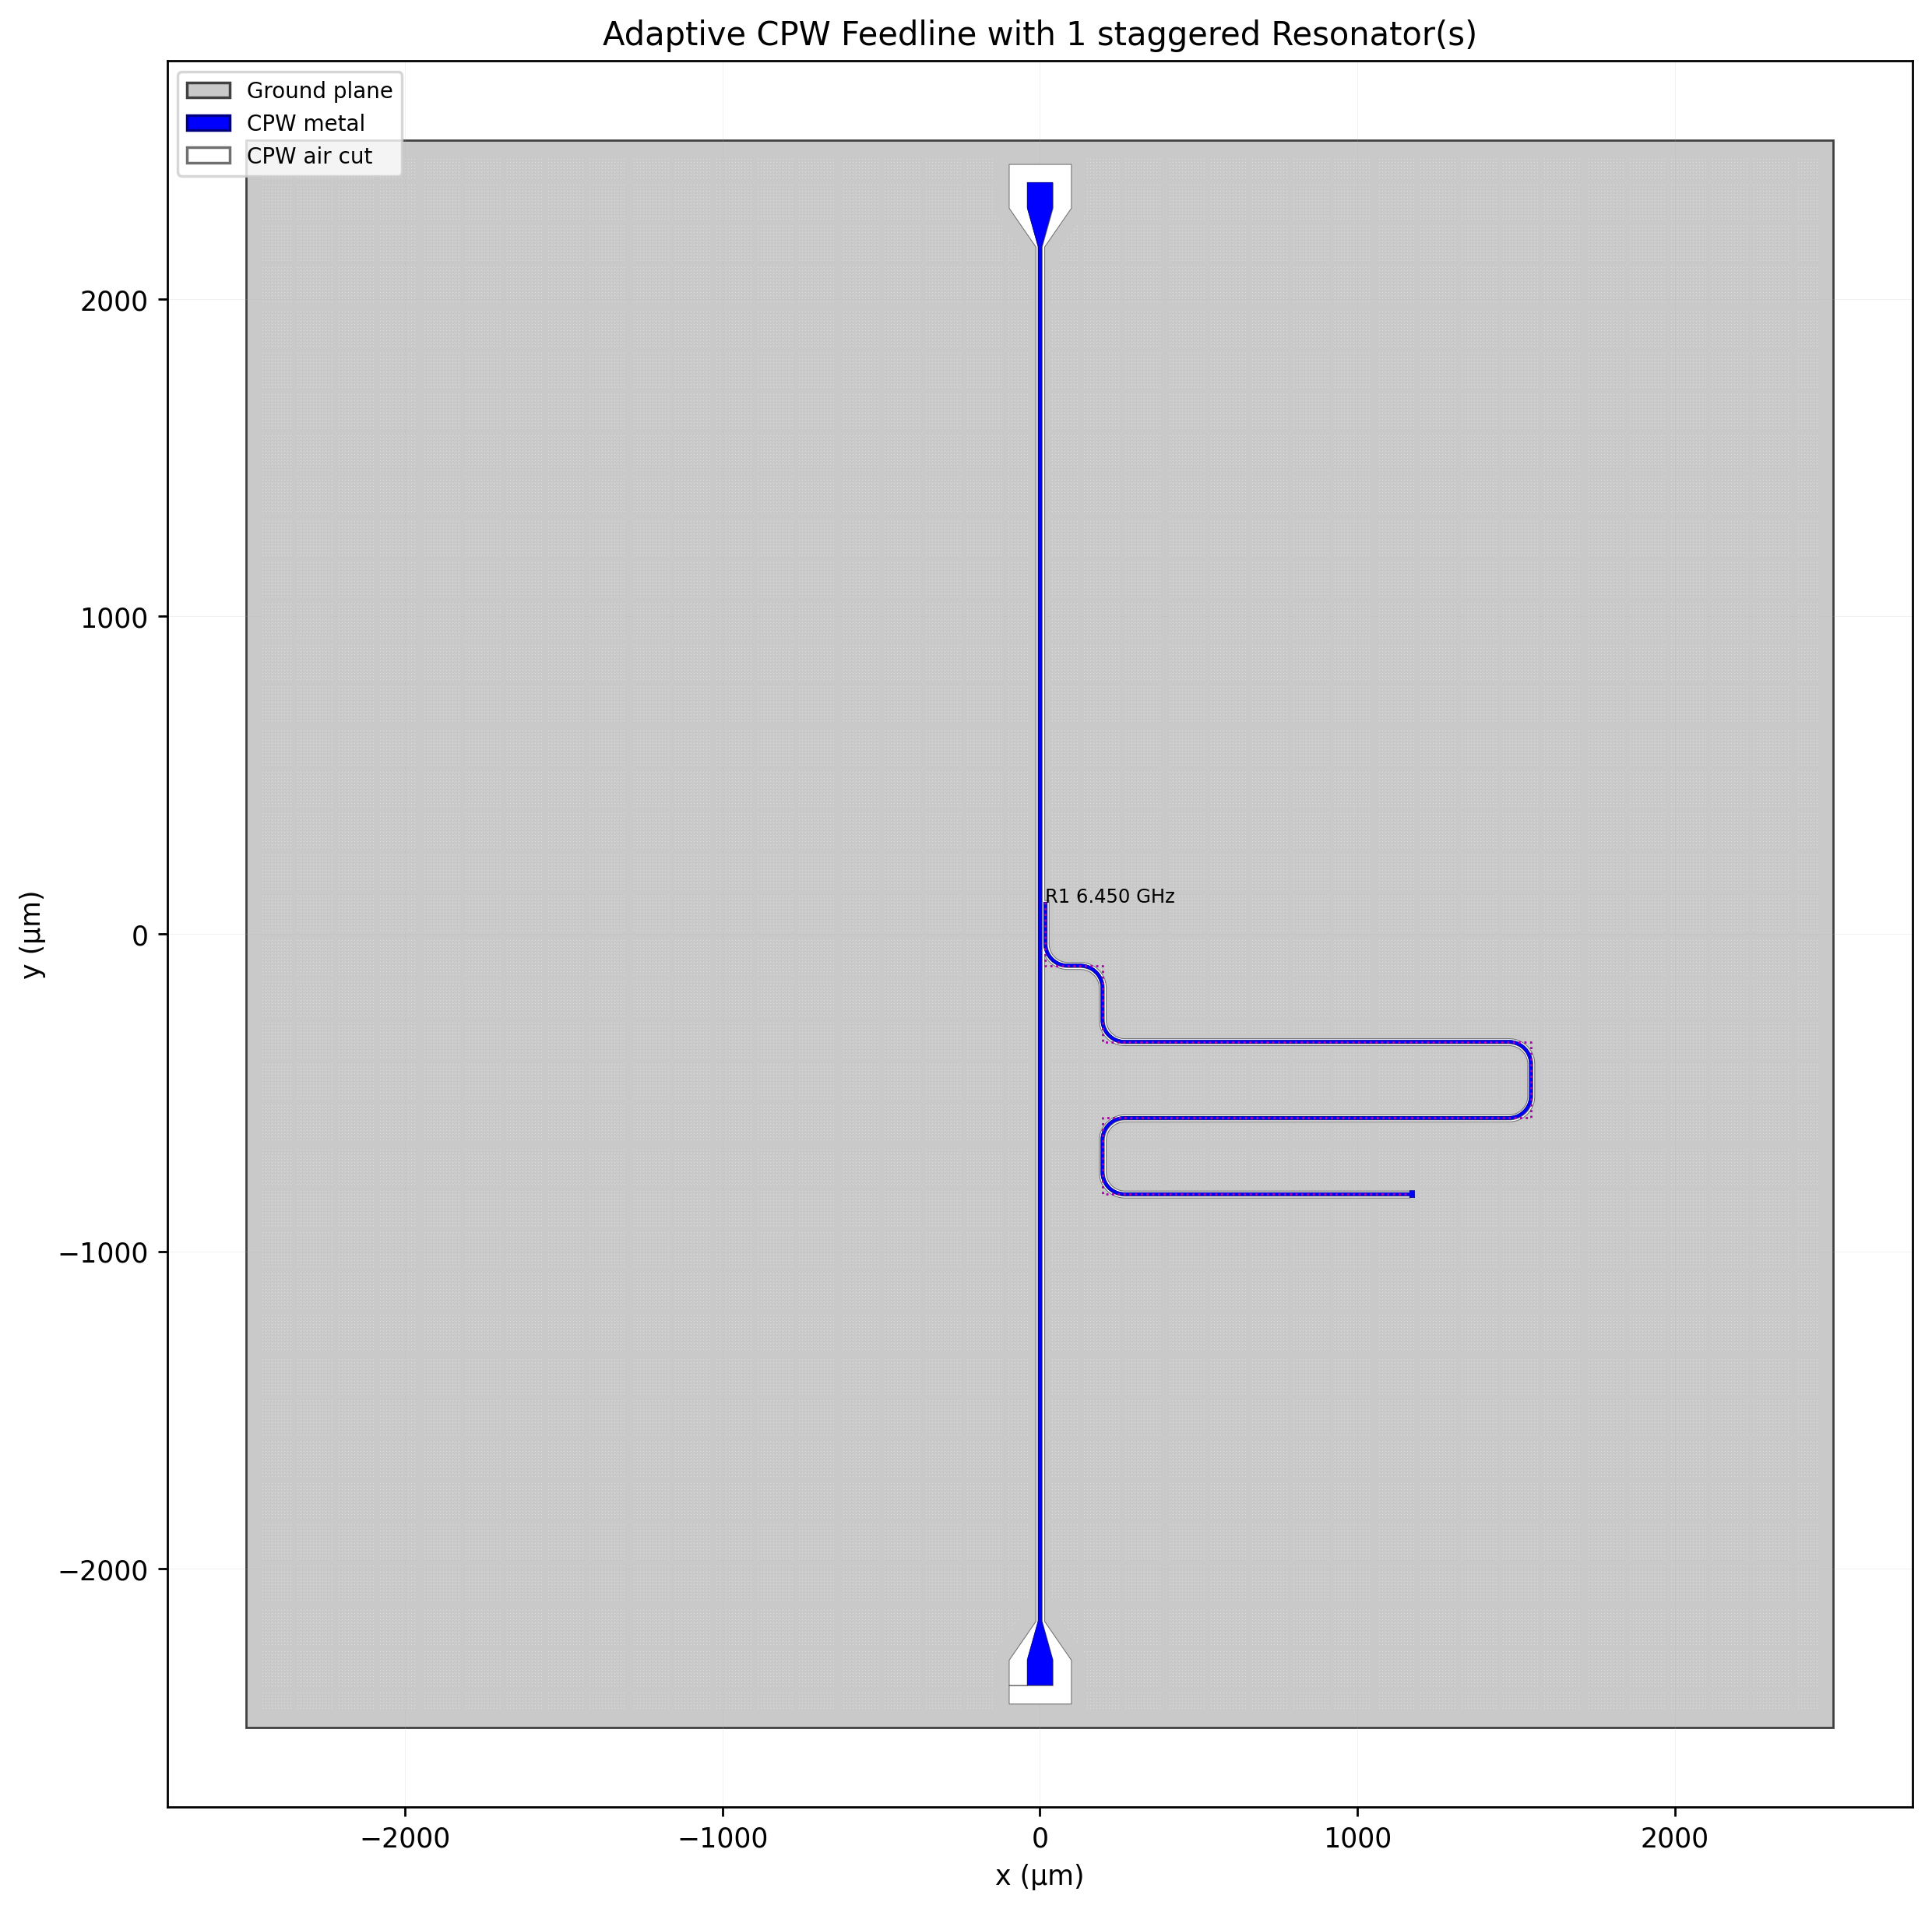

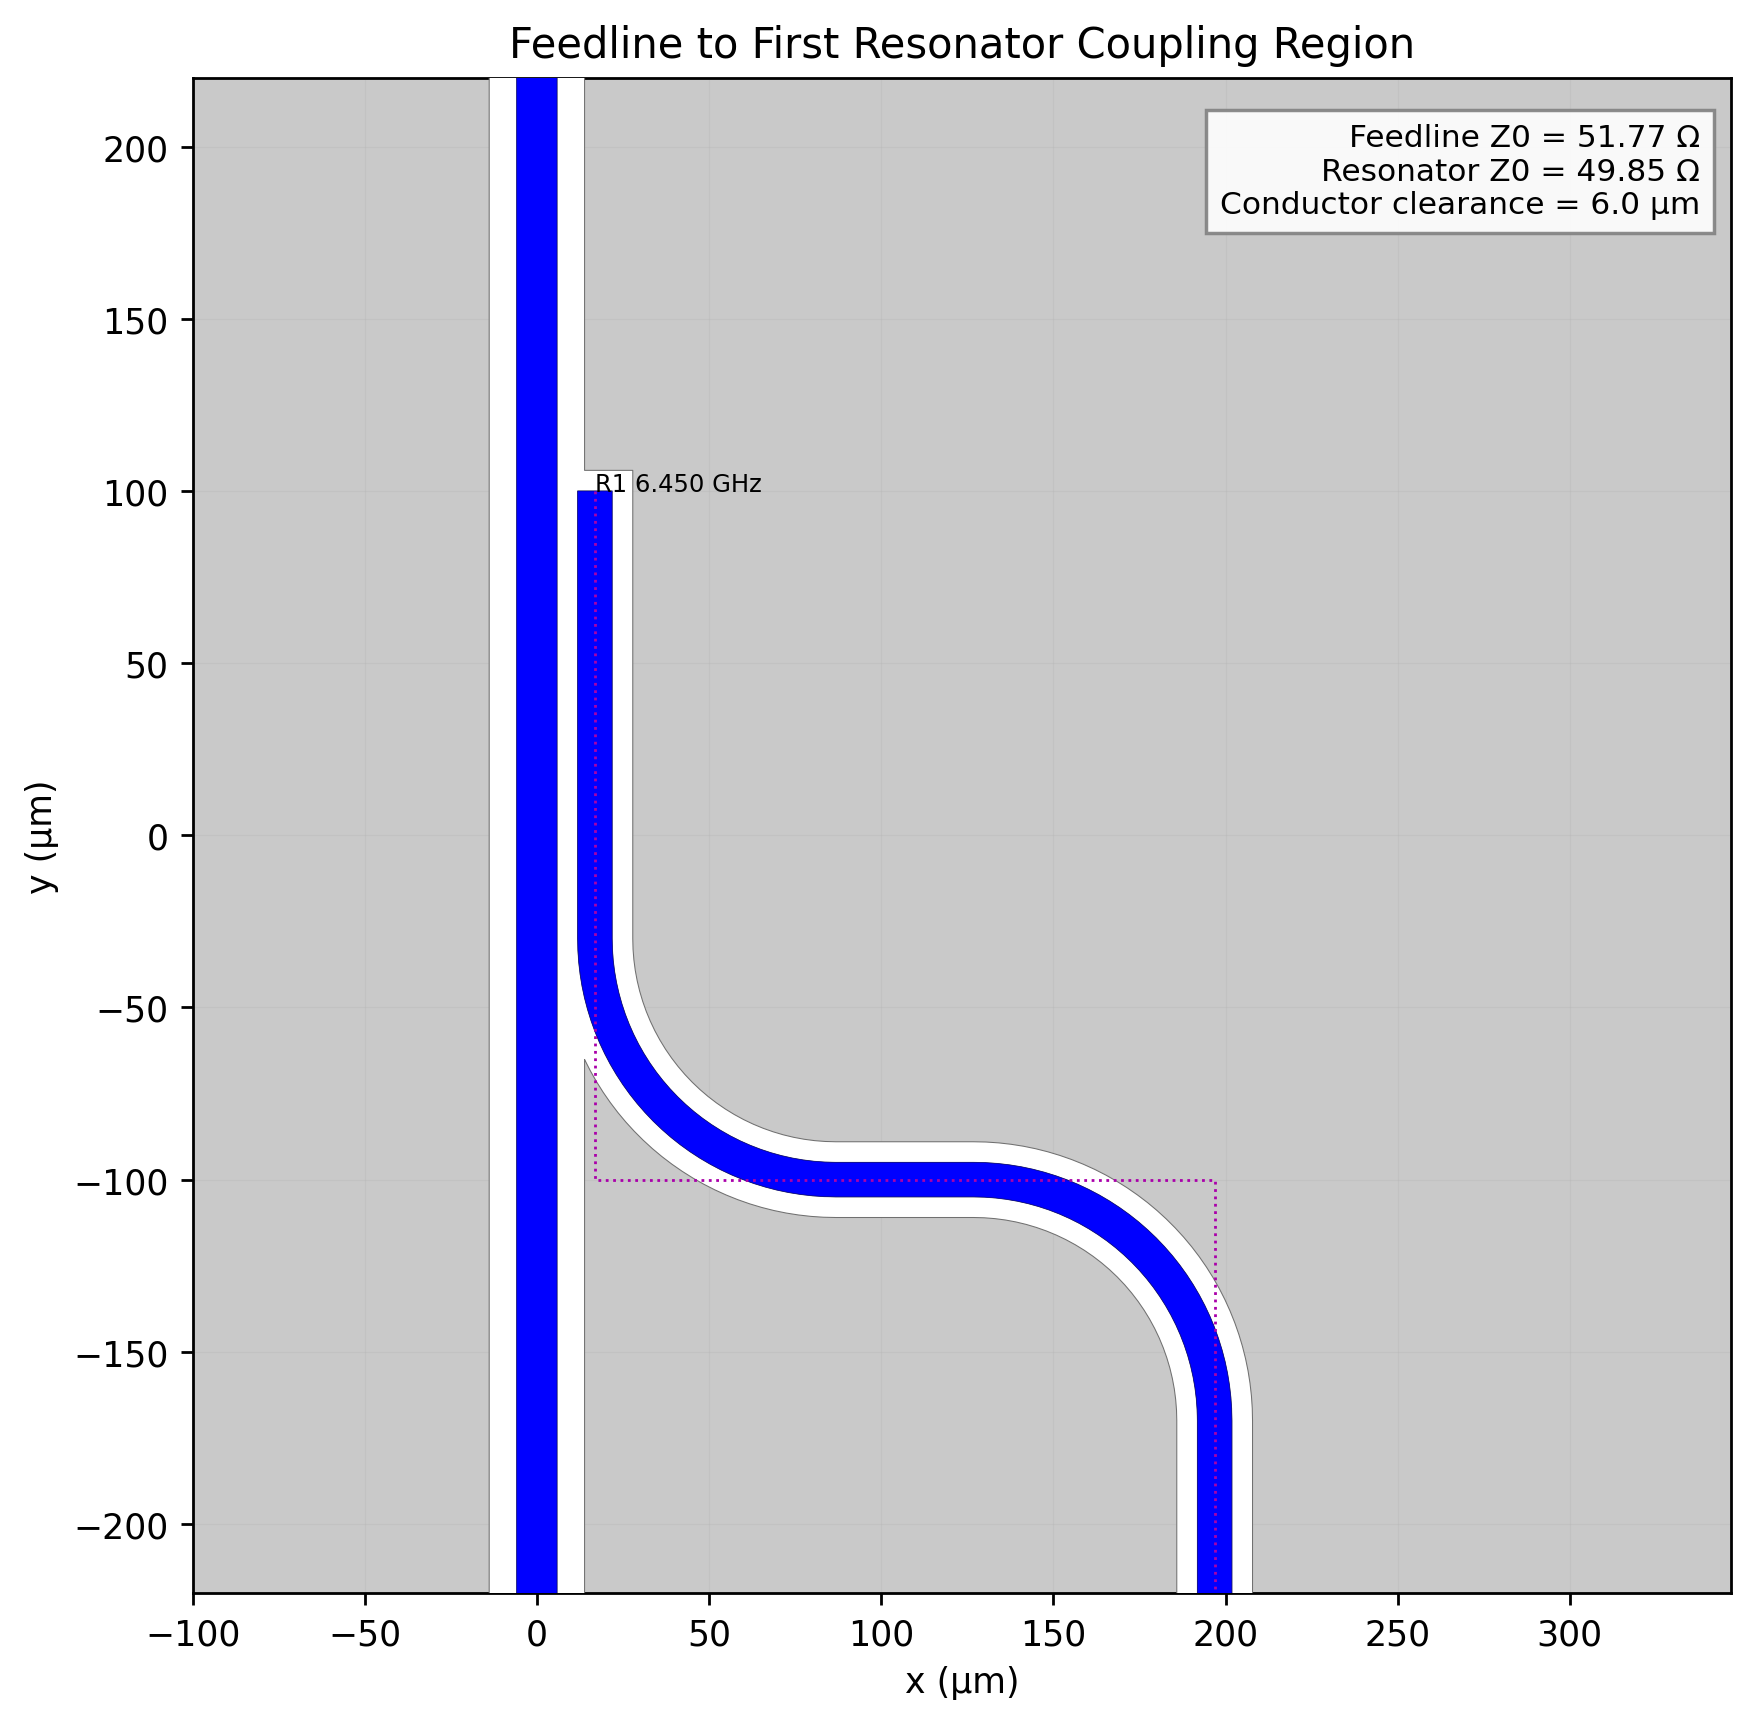

In [3]:
"""Build a DRC-aware multi-resonator superconducting CPW layout.

The generator combines PHIDL and GDSTK geometry with NetworkX A* routing.
Resonators are instantiated only from the ordered target-frequency list. The
feedline attachment sites adapt to the requested count, resonator footprint,
and stagger mode. Ground-plane cheesing is pruned around microwave keepouts,
and the exported GDS is re-imported for verification.
"""

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Final, Literal, Sequence

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.patches import Rectangle
from phidl import Device


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/cpw_resonator_networkx_cheesing.gds"
)
WRITE_GDS: Final[bool] = True
VERIFY_GDS_AFTER_WRITE: Final[bool] = True
FLATTEN_GDS_BEFORE_WRITE: Final[bool] = True
DOWNLOAD_GDS_AFTER_WRITE: Final[bool] = False

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 10.0
FIGURE_HEIGHT_IN: Final[float] = 10.0
RENDER_FIRST_COUPLER_ZOOM: Final[bool] = True
SHOW_ROUTING_CENTERLINES: Final[bool] = True
SHOW_GUIDE_LAYERS_IN_GDS: Final[bool] = True

CHIP_SIZE_X_UM: Final[float] = 5000.0
CHIP_SIZE_Y_UM: Final[float] = 5000.0
GRID_UM: Final[float] = 0.005

GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9
BOOLEAN_PRECISION_UM: Final[float] = 1.0e-3

# Only the first DESIRED_RESONATOR_COUNT entries are generated.
# Add frequencies here before increasing DESIRED_RESONATOR_COUNT.
TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    6.450,
)
DESIRED_RESONATOR_COUNT: Final[int] = 1

# Staggered means alternating resonators across opposite feedline sides.
STAGGER_RESONATORS: Final[bool] = True
NON_STAGGERED_SIDE: Final[Literal["left", "right"]] = "right"
PREFERRED_RESONATOR_SITE_PITCH_UM: Final[float] = 760.0
RESONATOR_SITE_END_MARGIN_UM: Final[float] = 120.0

RESONATOR_TOPOLOGY: Final[Literal["quarter_wave", "half_wave"]] = (
    "quarter_wave"
)
RESONATOR_FAR_TERMINATION: Final[Literal["open", "short"]] = "short"

CPW_EFFECTIVE_PERMITTIVITY: Final[float] = 6.50
CPW_TARGET_IMPEDANCE_OHM: Final[float] = 50.0
CPW_IMPEDANCE_TOLERANCE_FRACTION: Final[float] = 0.05
SPEED_OF_LIGHT_M_PER_S: Final[float] = 299_792_458.0

FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7
FEEDLINE_TRACE_GAP_UM: Final[float] = 8.0

RESONATOR_TRACE_WIDTH_UM: Final[float] = 10.0
RESONATOR_TRACE_GAP_UM: Final[float] = 6.0
RESONATOR_COUPLING_SPACE_UM: Final[float] = 6.0
RESONATOR_COUPLING_LENGTH_UM: Final[float] = 200.0
RESONATOR_LEAD_START_UM: Final[float] = 180.0
RESONATOR_MEANDER_PITCH_UM: Final[float] = 240.0
RESONATOR_MEANDER_SPAN_UM: Final[float] = 1350.0
RESONATOR_FILLET_UM: Final[float] = 70.0
OPEN_END_GAP_EXTENSION_UM: Final[float] = RESONATOR_TRACE_GAP_UM
SHORT_TERMINATION_DEPTH_UM: Final[float] = 16.0

# A* uses a rectilinear waypoint lattice and obstacle rectangles.
ENABLE_NETWORKX_ROUTING: Final[bool] = True
ROUTING_GRID_UM: Final[float] = 160.0
ROUTING_DETOUR_MARGIN_UM: Final[float] = 240.0
ROUTING_OBSTACLE_CLEARANCE_UM: Final[float] = 24.0
ROUTING_MAX_GRAPH_NODES: Final[int] = 12_000

FILLET_SAFETY_FRACTION: Final[float] = 0.46
CENTERLINE_LENGTH_TOLERANCE_UM: Final[float] = 0.01
LENGTH_SOLVER_MAX_ITERATIONS: Final[int] = 14

AUTO_PLACE_LAUNCHERS_FROM_DIE_RULES: Final[bool] = True
LAUNCHER_CENTER_Y_OVERRIDE_UM: Final[float | None] = None
LAUNCHER_EDGE_MARGIN_UM: Final[float] = 75.0
LAUNCHER_LEAD_LENGTH_UM: Final[float] = 25.0
LAUNCHER_PAD_WIDTH_UM: Final[float] = 80.0
LAUNCHER_PAD_HEIGHT_UM: Final[float] = 80.0
LAUNCHER_PAD_GAP_UM: Final[float] = 58.0
LAUNCHER_TAPER_HEIGHT_UM: Final[float] = 122.0
TOP_LAUNCHER_ORIENTATION_DEG: Final[float] = -90.0
BOTTOM_LAUNCHER_ORIENTATION_DEG: Final[float] = 90.0

ENABLE_CHEESING: Final[bool] = True
CHEESE_PITCH_UM: Final[float] = 10.0
CHEESE_SIZE_UM: Final[float] = 2.0
CHEESE_OFFSET_X_UM: Final[float] = 9.0
CHEESE_OFFSET_Y_UM: Final[float] = 0.0
CHEESE_MICROWAVE_KEEPOUT_UM: Final[float] = 15.0
CHEESE_LAUNCHER_KEEPOUT_UM: Final[float] = 45.0
CHEESE_EDGE_KEEPOUT_UM: Final[float] = 50.0

GROUND_FACE: Final[str] = "#C9C9C9"
CHIP_EDGE: Final[str] = "#404040"
METAL_FACE: Final[str] = "#0000FF"
METAL_EDGE: Final[str] = "#000080"
AIR_FACE: Final[str] = "#FFFFFF"
AIR_EDGE: Final[str] = "#707070"
CHEESE_FACE: Final[str] = "#FFFFFF"
CHEESE_ALPHA: Final[float] = 0.45
ROUTE_GUIDE_COLOR: Final[str] = "#AA00AA"

mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["figure.dpi"] = MPL_DPI


# -----------------------------------------------------------------------------
# Layer map and design-rule deck
# -----------------------------------------------------------------------------

METAL_LAYER: Final[int] = 3
METAL_DATATYPE: Final[int] = 0
AIR_CUT_LAYER: Final[int] = 3
AIR_CUT_DATATYPE: Final[int] = 1
CHEESE_LAYER: Final[int] = 3
CHEESE_DATATYPE: Final[int] = 2

DIE_OUTLINE_LAYER: Final[int] = 100
DIE_OUTLINE_DATATYPE: Final[int] = 0
EDGE_KEEPOUT_LAYER: Final[int] = 101
EDGE_KEEPOUT_DATATYPE: Final[int] = 0
ROUTING_GUIDE_LAYER: Final[int] = 102
ROUTING_GUIDE_DATATYPE: Final[int] = 0
DRC_MARKER_LAYER: Final[int] = 103
DRC_MARKER_DATATYPE: Final[int] = 0

METAL_SPEC: Final[tuple[int, int]] = (METAL_LAYER, METAL_DATATYPE)
FOOTPRINT_SPEC: Final[tuple[int, int]] = (AIR_CUT_LAYER, AIR_CUT_DATATYPE)


@dataclass(frozen=True)
class DesignRules:
    """Store fabrication and microwave geometry limits in micrometers."""

    grid_um: float = GRID_UM
    min_width_um: float = 2.0
    min_space_um: float = 2.0
    junction_critical_width_um: float = 0.10
    junction_enclosure_um: float = 0.20
    die_keepout_um: float = 50.0
    taper_min_angle_deg: float = 10.0
    min_cpw_gap_um: float = 3.0
    min_bend_radius_factor: float = 2.5
    impedance_target_ohm: float = CPW_TARGET_IMPEDANCE_OHM
    impedance_tolerance_fraction: float = CPW_IMPEDANCE_TOLERANCE_FRACTION


RULES: Final[DesignRules] = DesignRules()


@dataclass(frozen=True)
class RectObstacle:
    """Represent an axis-aligned routing keepout rectangle."""

    x_min: float
    y_min: float
    x_max: float
    y_max: float
    label: str

    def expanded(self, margin_um: float) -> "RectObstacle":
        """Return a rectangle expanded by the requested clearance."""

        return RectObstacle(
            x_min=self.x_min - margin_um,
            y_min=self.y_min - margin_um,
            x_max=self.x_max + margin_um,
            y_max=self.y_max + margin_um,
            label=self.label,
        )


@dataclass
class ResonatorResult:
    """Store geometry and route diagnostics for one resonator."""

    index: int
    frequency_ghz: float
    side: int
    coupler_center_y_um: float
    centerline_points: np.ndarray
    nominal_points: np.ndarray
    conductor_polygons: list[gdstk.Polygon]
    footprint_polygons: list[gdstk.Polygon]
    target_length_um: float
    rounded_length_um: float
    fillet_um: float
    predicted_frequency_ghz: float
    routing_graph_nodes: int
    routing_graph_edges: int
    routing_path_length_um: float


@dataclass
class LayoutResult:
    """Store generated PHIDL, GDSTK, resonator, and audit information."""

    phidl_device: Device
    library: gdstk.Library
    top_cell: gdstk.Cell
    conductor_polygons: list[gdstk.Polygon]
    air_cut_polygons: list[gdstk.Polygon]
    ordinary_footprints: list[gdstk.Polygon]
    launcher_footprints: list[gdstk.Polygon]
    resonators: list[ResonatorResult]
    cheese_points: np.ndarray
    cheese_references: list[gdstk.Reference]
    candidate_cheese_count: int
    feedline_x_um: float
    feedline_y_min_um: float
    feedline_y_max_um: float
    feedline_z0_ohm: float
    resonator_z0_ohm: float
    max_grid_error_um: float
    gds_path: Path
    gds_size_bytes: int
    reimported_polygon_count: int


@dataclass(frozen=True)
class RouteStats:
    """Store cumulative NetworkX graph diagnostics."""

    node_count: int
    edge_count: int
    path_length_um: float


# -----------------------------------------------------------------------------
# Grid and geometry helpers
# -----------------------------------------------------------------------------


def snap_value_um(value: float) -> float:
    """Snap one coordinate to the global fabrication grid."""

    return round(value / RULES.grid_um) * RULES.grid_um


def snap_points_um(points: np.ndarray) -> np.ndarray:
    """Snap an array of xy coordinates to the global fabrication grid."""

    points = np.asarray(points, dtype=np.float64)
    return np.round(points / RULES.grid_um) * RULES.grid_um


def deduplicate_adjacent_points(points: np.ndarray) -> np.ndarray:
    """Remove duplicate neighboring vertices from a centerline or polygon."""

    points = np.asarray(points, dtype=np.float64)
    if points.shape[0] <= 1:
        return points.copy()

    delta = np.linalg.norm(np.diff(points, axis=0), axis=1)
    keep = np.concatenate(([True], delta > 1.0e-12))
    return points[keep]


def compress_collinear_points(points: np.ndarray) -> np.ndarray:
    """Remove internal points that lie on straight centerline segments."""

    points = deduplicate_adjacent_points(snap_points_um(points))
    if points.shape[0] <= 2:
        return points

    keep: list[np.ndarray] = [points[0]]
    for index in range(1, points.shape[0] - 1):
        previous = points[index] - points[index - 1]
        following = points[index + 1] - points[index]
        cross = previous[0] * following[1] - previous[1] * following[0]
        if abs(cross) > 1.0e-9:
            keep.append(points[index])
    keep.append(points[-1])
    return np.asarray(keep, dtype=np.float64)


def snap_polygon(polygon: gdstk.Polygon) -> gdstk.Polygon:
    """Return one GDSTK polygon with every vertex snapped to the grid."""

    points = deduplicate_adjacent_points(snap_points_um(polygon.points))
    if points.shape[0] > 2 and np.allclose(points[0], points[-1]):
        points = points[:-1]
    if points.shape[0] < 3:
        raise ValueError("Grid snapping collapsed a polygon below three vertices.")
    return gdstk.Polygon(
        points,
        layer=polygon.layer,
        datatype=polygon.datatype,
    )


def snap_polygons(polygons: Sequence[gdstk.Polygon]) -> list[gdstk.Polygon]:
    """Snap every polygon in a collection to the global grid."""

    return [snap_polygon(polygon) for polygon in polygons]


def add_rectangle(
    device: Device,
    x0: float,
    y0: float,
    x1: float,
    y1: float,
    layer: tuple[int, int],
) -> None:
    """Add a snapped axis-aligned rectangle to a PHIDL device."""

    x_min = snap_value_um(min(x0, x1))
    x_max = snap_value_um(max(x0, x1))
    y_min = snap_value_um(min(y0, y1))
    y_max = snap_value_um(max(y0, y1))
    device.add_polygon(
        [
            (x_min, y_min),
            (x_max, y_min),
            (x_max, y_max),
            (x_min, y_max),
        ],
        layer=layer,
    )


def union_polygons(
    polygons: Sequence[gdstk.Polygon],
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Return the Boolean union of a polygon collection."""

    if len(polygons) == 0:
        return []
    result = gdstk.boolean(
        list(polygons),
        [],
        "or",
        precision=BOOLEAN_PRECISION_UM,
        layer=layer,
        datatype=datatype,
    )
    return snap_polygons(result)


def phidl_polygons_to_gdstk(
    device: Device,
    spec: tuple[int, int],
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert one PHIDL layer specification to snapped GDSTK polygons."""

    polygons_by_spec = device.get_polygons(by_spec=True)
    polygon_arrays = polygons_by_spec.get(spec, [])
    polygons = [
        gdstk.Polygon(
            snap_points_um(np.asarray(points, dtype=np.float64)),
            layer=layer,
            datatype=datatype,
        )
        for points in polygon_arrays
    ]
    return snap_polygons(polygons)


def polyline_length_um(points: np.ndarray) -> float:
    """Return the piecewise-linear centerline length."""

    points = np.asarray(points, dtype=np.float64)
    if points.shape[0] < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(points, axis=0), axis=1)))


def bounding_box_for_polygons(
    polygons: Sequence[gdstk.Polygon],
) -> tuple[float, float, float, float]:
    """Return one bounding rectangle for a non-empty polygon collection."""

    if len(polygons) == 0:
        raise ValueError("A bounding box requires at least one polygon.")

    boxes = [polygon.bounding_box() for polygon in polygons]
    x_min = min(float(box[0][0]) for box in boxes)
    y_min = min(float(box[0][1]) for box in boxes)
    x_max = max(float(box[1][0]) for box in boxes)
    y_max = max(float(box[1][1]) for box in boxes)
    return x_min, y_min, x_max, y_max


def polygon_obstacle(
    polygons: Sequence[gdstk.Polygon],
    label: str,
    margin_um: float = 0.0,
) -> RectObstacle:
    """Create a rectangular routing keepout from polygon bounds."""

    x_min, y_min, x_max, y_max = bounding_box_for_polygons(polygons)
    return RectObstacle(x_min, y_min, x_max, y_max, label).expanded(margin_um)


# -----------------------------------------------------------------------------
# CPW electrical model
# -----------------------------------------------------------------------------


def complete_elliptic_k_modulus(k: float) -> float:
    """Evaluate the complete elliptic integral K(k) by the AGM method."""

    if not 0.0 <= k < 1.0:
        raise ValueError("Elliptic modulus k must satisfy 0 <= k < 1.")

    a_value = 1.0
    b_value = math.sqrt(1.0 - k * k)
    for _ in range(64):
        next_a = 0.5 * (a_value + b_value)
        next_b = math.sqrt(a_value * b_value)
        a_value = next_a
        b_value = next_b
        if abs(a_value - b_value) <= 1.0e-15:
            break
    return math.pi / (2.0 * a_value)


def cpw_characteristic_impedance_ohm(
    trace_width_um: float,
    gap_um: float,
    effective_permittivity: float,
) -> float:
    """Estimate CPW impedance with the conformal-mapping elliptic formula."""

    if trace_width_um <= 0.0 or gap_um <= 0.0:
        raise ValueError("CPW width and gap must be positive.")
    if effective_permittivity <= 1.0:
        raise ValueError("Effective permittivity must exceed unity.")

    modulus = trace_width_um / (trace_width_um + 2.0 * gap_um)
    complementary = math.sqrt(1.0 - modulus * modulus)
    k_value = complete_elliptic_k_modulus(modulus)
    kp_value = complete_elliptic_k_modulus(complementary)
    return (
        30.0
        * math.pi
        / math.sqrt(effective_permittivity)
        * kp_value
        / k_value
    )


def cpw_phase_velocity_m_per_s() -> float:
    """Return the quasi-TEM phase velocity from effective permittivity."""

    return SPEED_OF_LIGHT_M_PER_S / math.sqrt(CPW_EFFECTIVE_PERMITTIVITY)


def electrical_length_um(frequency_ghz: float) -> float:
    """Return first-pass quarter-wave or half-wave centerline length."""

    if frequency_ghz <= 0.0:
        raise ValueError("Resonator frequency must be positive.")

    divisor = 4.0 if RESONATOR_TOPOLOGY == "quarter_wave" else 2.0
    return (
        cpw_phase_velocity_m_per_s()
        / (divisor * frequency_ghz * 1.0e9)
        * 1.0e6
    )


def frequency_from_length_ghz(length_um: float) -> float:
    """Map an idealized centerline length back to resonant frequency."""

    if length_um <= 0.0:
        raise ValueError("Centerline length must be positive.")
    divisor = 4.0 if RESONATOR_TOPOLOGY == "quarter_wave" else 2.0
    return cpw_phase_velocity_m_per_s() / (divisor * length_um * 1.0e3)


# -----------------------------------------------------------------------------
# Launcher and feedline geometry
# -----------------------------------------------------------------------------


def launcher_pocket_depth_um() -> float:
    """Return the longitudinal launcher pocket depth from its local origin."""

    return (
        LAUNCHER_TAPER_HEIGHT_UM
        + LAUNCHER_PAD_HEIGHT_UM
        + LAUNCHER_PAD_GAP_UM
    )


def launcher_metal_depth_um() -> float:
    """Return the longitudinal positive-metal depth from launcher origin."""

    return LAUNCHER_TAPER_HEIGHT_UM + LAUNCHER_PAD_HEIGHT_UM


def compute_launcher_center_y_um() -> float:
    """Place launcher origins within the die and edge keepout rules."""

    if LAUNCHER_CENTER_Y_OVERRIDE_UM is not None:
        return snap_value_um(abs(LAUNCHER_CENTER_Y_OVERRIDE_UM))

    if not AUTO_PLACE_LAUNCHERS_FROM_DIE_RULES:
        return 2100.0

    chip_half_y = CHIP_SIZE_Y_UM / 2.0
    edge_margin = max(RULES.die_keepout_um, LAUNCHER_EDGE_MARGIN_UM)
    center_y = chip_half_y - edge_margin - launcher_pocket_depth_um()
    if center_y <= 0.0:
        raise ValueError("Launcher dimensions leave no legal feedline region.")
    return snap_value_um(center_y)


def estimate_meander_drop_um(target_length_um: float) -> float:
    """Estimate downward meander occupancy for feedline-site planning."""

    base_length = RESONATOR_COUPLING_LENGTH_UM + RESONATOR_LEAD_START_UM
    remaining = max(0.0, target_length_um - base_length)
    drop = 0.0
    for _ in range(128):
        if remaining <= 1.0e-12:
            break
        vertical = min(RESONATOR_MEANDER_PITCH_UM, remaining)
        drop += vertical
        remaining -= vertical
        if remaining <= 1.0e-12:
            break
        horizontal = min(RESONATOR_MEANDER_SPAN_UM, remaining)
        remaining -= horizontal
    if remaining > 1.0e-6:
        raise RuntimeError("Meander occupancy estimator exceeded iteration limit.")
    return drop


def compute_feedline_x_um(target_lengths_um: Sequence[float]) -> float:
    """Shift the backbone only if a one-sided resonator set needs more room."""

    if STAGGER_RESONATORS or len(target_lengths_um) == 0:
        return 0.0

    side = 1.0 if NON_STAGGERED_SIDE == "right" else -1.0
    inner_half_x = CHIP_SIZE_X_UM / 2.0 - RULES.die_keepout_um
    resonator_outer_half = (
        RESONATOR_TRACE_WIDTH_UM + 2.0 * RESONATOR_TRACE_GAP_UM
    ) / 2.0
    required_reach = (
        FEEDLINE_TRACE_WIDTH_UM / 2.0
        + RESONATOR_COUPLING_SPACE_UM
        + RESONATOR_TRACE_WIDTH_UM / 2.0
        + RESONATOR_LEAD_START_UM
        + RESONATOR_MEANDER_SPAN_UM
        + resonator_outer_half
        + RULES.min_space_um
    )

    if required_reach <= inner_half_x:
        return 0.0

    shift_magnitude = required_reach - inner_half_x
    return snap_value_um(-side * shift_magnitude)


def create_launchpad_wirebond(
    name: str,
    pos_x_um: float,
    pos_y_um: float,
    orientation_deg: float,
) -> Device:
    """Create a Qiskit-Metal-style wirebond launcher and ground pocket."""

    device = Device(name)
    trace_half = FEEDLINE_TRACE_WIDTH_UM / 2.0
    pad_half = LAUNCHER_PAD_WIDTH_UM / 2.0
    lead_length = LAUNCHER_LEAD_LENGTH_UM
    taper_height = LAUNCHER_TAPER_HEIGHT_UM
    pad_height = LAUNCHER_PAD_HEIGHT_UM
    pad_gap = LAUNCHER_PAD_GAP_UM
    trace_gap = FEEDLINE_TRACE_GAP_UM

    launch_pad = [
        (0.0, trace_half),
        (-taper_height, pad_half),
        (-(pad_height + taper_height), pad_half),
        (-(pad_height + taper_height), -pad_half),
        (-taper_height, -pad_half),
        (0.0, -trace_half),
        (lead_length, -trace_half),
        (lead_length, trace_half),
    ]
    pocket = [
        (0.0, trace_half + trace_gap),
        (-taper_height, pad_half + pad_gap),
        (-(pad_height + taper_height + pad_gap), pad_half + pad_gap),
        (-(pad_height + taper_height + pad_gap), -(pad_half + pad_gap)),
        (-taper_height, -(pad_half + pad_gap)),
        (0.0, -(trace_half + trace_gap)),
        (lead_length, -(trace_half + trace_gap)),
        (lead_length, trace_half + trace_gap),
    ]

    device.add_polygon(snap_points_um(np.asarray(launch_pad)), layer=METAL_SPEC)
    device.add_polygon(snap_points_um(np.asarray(pocket)), layer=FOOTPRINT_SPEC)
    device.add_port(
        name="tie",
        midpoint=(lead_length, 0.0),
        width=FEEDLINE_TRACE_WIDTH_UM,
        orientation=0.0,
    )
    device.rotate(angle=orientation_deg, center=(0.0, 0.0))
    device.move(origin=(0.0, 0.0), destination=(pos_x_um, pos_y_um))
    return device


def create_feedline(top_launcher: Device, bottom_launcher: Device) -> Device:
    """Create the adaptive straight CPW backbone between launcher tie ports."""

    device = Device("feedline")
    top_pin = np.asarray(top_launcher.ports["tie"].midpoint, dtype=np.float64)
    bottom_pin = np.asarray(
        bottom_launcher.ports["tie"].midpoint,
        dtype=np.float64,
    )
    center_x = snap_value_um(0.5 * (top_pin[0] + bottom_pin[0]))
    y_min = snap_value_um(min(top_pin[1], bottom_pin[1]))
    y_max = snap_value_um(max(top_pin[1], bottom_pin[1]))
    conductor_half = FEEDLINE_TRACE_WIDTH_UM / 2.0
    footprint_half = conductor_half + FEEDLINE_TRACE_GAP_UM

    add_rectangle(
        device,
        center_x - conductor_half,
        y_min,
        center_x + conductor_half,
        y_max,
        METAL_SPEC,
    )
    add_rectangle(
        device,
        center_x - footprint_half,
        y_min,
        center_x + footprint_half,
        y_max,
        FOOTPRINT_SPEC,
    )
    return device


# -----------------------------------------------------------------------------
# Adaptive resonator site planning
# -----------------------------------------------------------------------------


def selected_target_frequencies_ghz() -> tuple[float, ...]:
    """Return exactly the requested prefix of the target-frequency list."""

    if DESIRED_RESONATOR_COUNT < 1:
        raise ValueError("DESIRED_RESONATOR_COUNT must be at least 1.")
    if DESIRED_RESONATOR_COUNT > len(TARGET_RESONATOR_FREQUENCIES_GHZ):
        raise ValueError(
            "DESIRED_RESONATOR_COUNT exceeds the number of available target "
            "frequencies. Add frequencies to TARGET_RESONATOR_FREQUENCIES_GHZ."
        )
    frequencies = TARGET_RESONATOR_FREQUENCIES_GHZ[:DESIRED_RESONATOR_COUNT]
    if any(frequency <= 0.0 for frequency in frequencies):
        raise ValueError("Every target resonator frequency must be positive.")
    return tuple(float(frequency) for frequency in frequencies)


def resonator_side_for_index(index: int) -> int:
    """Return +1 for right placement and -1 for left placement."""

    if STAGGER_RESONATORS:
        return 1 if index % 2 == 0 else -1
    return 1 if NON_STAGGERED_SIDE == "right" else -1


def minimum_site_pitch_um(target_lengths_um: Sequence[float]) -> float:
    """Calculate spacing needed for same-side meander envelopes."""

    if len(target_lengths_um) == 0:
        return PREFERRED_RESONATOR_SITE_PITCH_UM

    outer_width = RESONATOR_TRACE_WIDTH_UM + 2.0 * RESONATOR_TRACE_GAP_UM
    max_drop = max(estimate_meander_drop_um(length) for length in target_lengths_um)
    resonator_height = RESONATOR_COUPLING_LENGTH_UM + max_drop + outer_width
    same_side_pitch = resonator_height + 2.0 * RULES.min_space_um
    if STAGGER_RESONATORS:
        same_side_pitch *= 0.5

    coupling_pitch = (
        RESONATOR_COUPLING_LENGTH_UM
        + RESONATOR_TRACE_WIDTH_UM
        + 2.0 * RULES.min_space_um
    )
    return snap_value_um(max(coupling_pitch, same_side_pitch))


def plan_resonator_sites_y_um(
    target_lengths_um: Sequence[float],
    feedline_y_min_um: float,
    feedline_y_max_um: float,
) -> np.ndarray:
    """Place resonators in list order along the available feedline length."""

    count = len(target_lengths_um)
    if count == 0:
        return np.empty(0, dtype=np.float64)

    outer_half = (
        RESONATOR_TRACE_WIDTH_UM + 2.0 * RESONATOR_TRACE_GAP_UM
    ) / 2.0
    max_drop = max(estimate_meander_drop_um(length) for length in target_lengths_um)
    center_max = (
        feedline_y_max_um
        - RESONATOR_SITE_END_MARGIN_UM
        - RESONATOR_COUPLING_LENGTH_UM / 2.0
        - outer_half
    )
    center_min = (
        feedline_y_min_um
        + RESONATOR_SITE_END_MARGIN_UM
        + RESONATOR_COUPLING_LENGTH_UM / 2.0
        + max_drop
        + outer_half
    )
    if center_min > center_max:
        raise ValueError("The die is too short for the requested resonator geometry.")

    if count == 1:
        if center_min <= 0.0 <= center_max:
            return np.asarray([0.0], dtype=np.float64)
        return np.asarray(
            [snap_value_um(0.5 * (center_min + center_max))],
            dtype=np.float64,
        )

    minimum_pitch = minimum_site_pitch_um(target_lengths_um)
    maximum_fit_pitch = (center_max - center_min) / (count - 1)
    if maximum_fit_pitch + 1.0e-9 < minimum_pitch:
        raise ValueError(
            "The requested resonator count cannot satisfy same-side footprint "
            "spacing on this die. Reduce count, shrink the meander, or use "
            "staggered placement."
        )

    pitch = min(PREFERRED_RESONATOR_SITE_PITCH_UM, maximum_fit_pitch)
    pitch = max(pitch, minimum_pitch)
    pitch = snap_value_um(pitch)
    span = pitch * (count - 1)
    midpoint = 0.5 * (center_min + center_max)
    top_center = midpoint + 0.5 * span
    centers = np.asarray(
        [top_center - index * pitch for index in range(count)],
        dtype=np.float64,
    )
    return snap_points_um(np.column_stack((np.zeros(count), centers)))[:, 1]


# -----------------------------------------------------------------------------
# NetworkX rectilinear routing
# -----------------------------------------------------------------------------


def point_inside_obstacle(point: tuple[float, float], obstacle: RectObstacle) -> bool:
    """Return whether a waypoint lies inside or on a routing obstacle."""

    x_value, y_value = point
    return (
        obstacle.x_min - 1.0e-9 <= x_value <= obstacle.x_max + 1.0e-9
        and obstacle.y_min - 1.0e-9 <= y_value <= obstacle.y_max + 1.0e-9
    )


def orthogonal_segment_hits_obstacle(
    start: tuple[float, float],
    end: tuple[float, float],
    obstacle: RectObstacle,
) -> bool:
    """Test one horizontal or vertical segment against an obstacle rectangle."""

    x0, y0 = start
    x1, y1 = end
    tolerance = 1.0e-9

    if abs(y0 - y1) <= tolerance:
        segment_min = min(x0, x1)
        segment_max = max(x0, x1)
        y_hits = obstacle.y_min - tolerance <= y0 <= obstacle.y_max + tolerance
        x_hits = not (
            segment_max < obstacle.x_min - tolerance
            or segment_min > obstacle.x_max + tolerance
        )
        return y_hits and x_hits

    if abs(x0 - x1) <= tolerance:
        segment_min = min(y0, y1)
        segment_max = max(y0, y1)
        x_hits = obstacle.x_min - tolerance <= x0 <= obstacle.x_max + tolerance
        y_hits = not (
            segment_max < obstacle.y_min - tolerance
            or segment_min > obstacle.y_max + tolerance
        )
        return x_hits and y_hits

    raise ValueError("Routing graph edges must be rectilinear.")


def routing_coordinates(
    minimum: float,
    maximum: float,
    anchors: Sequence[float],
) -> list[float]:
    """Build a snapped coordinate lattice that includes exact anchor values."""

    minimum = snap_value_um(minimum)
    maximum = snap_value_um(maximum)
    if maximum < minimum:
        minimum, maximum = maximum, minimum

    values = list(np.arange(minimum, maximum + ROUTING_GRID_UM, ROUTING_GRID_UM))
    values.extend(float(anchor) for anchor in anchors)
    snapped = sorted({snap_value_um(value) for value in values})
    return [value for value in snapped if minimum - 1.0e-9 <= value <= maximum + 1.0e-9]


def astar_rectilinear_route(
    start: np.ndarray,
    goal: np.ndarray,
    obstacles: Sequence[RectObstacle],
) -> tuple[np.ndarray, RouteStats]:
    """Route one Manhattan segment using a legal-waypoint NetworkX A* graph."""

    start = snap_points_um(np.asarray(start, dtype=np.float64).reshape(1, 2))[0]
    goal = snap_points_um(np.asarray(goal, dtype=np.float64).reshape(1, 2))[0]
    if np.allclose(start, goal):
        return np.asarray([start], dtype=np.float64), RouteStats(1, 0, 0.0)

    if not ENABLE_NETWORKX_ROUTING:
        direct = np.vstack((start, goal))
        return direct, RouteStats(2, 1, polyline_length_um(direct))

    x_min = min(start[0], goal[0]) - ROUTING_DETOUR_MARGIN_UM
    x_max = max(start[0], goal[0]) + ROUTING_DETOUR_MARGIN_UM
    y_min = min(start[1], goal[1]) - ROUTING_DETOUR_MARGIN_UM
    y_max = max(start[1], goal[1]) + ROUTING_DETOUR_MARGIN_UM

    relevant_obstacles = [
        obstacle
        for obstacle in obstacles
        if not (
            obstacle.x_max < x_min
            or obstacle.x_min > x_max
            or obstacle.y_max < y_min
            or obstacle.y_min > y_max
        )
    ]

    x_anchors = [start[0], goal[0]]
    y_anchors = [start[1], goal[1]]
    for obstacle in relevant_obstacles:
        x_anchors.extend(
            [
                obstacle.x_min - ROUTING_GRID_UM,
                obstacle.x_min,
                obstacle.x_max,
                obstacle.x_max + ROUTING_GRID_UM,
            ]
        )
        y_anchors.extend(
            [
                obstacle.y_min - ROUTING_GRID_UM,
                obstacle.y_min,
                obstacle.y_max,
                obstacle.y_max + ROUTING_GRID_UM,
            ]
        )

    x_values = routing_coordinates(x_min, x_max, x_anchors)
    y_values = routing_coordinates(y_min, y_max, y_anchors)
    graph = nx.Graph()

    for x_value in x_values:
        for y_value in y_values:
            node = (x_value, y_value)
            if node == tuple(start) or node == tuple(goal):
                graph.add_node(node)
                continue
            if any(point_inside_obstacle(node, obstacle) for obstacle in relevant_obstacles):
                continue
            graph.add_node(node)

    if graph.number_of_nodes() > ROUTING_MAX_GRAPH_NODES:
        raise RuntimeError(
            "NetworkX routing graph exceeded ROUTING_MAX_GRAPH_NODES. "
            "Increase ROUTING_GRID_UM or reduce the detour margin."
        )

    for y_value in y_values:
        row_nodes = [(x_value, y_value) for x_value in x_values]
        for first, second in zip(row_nodes[:-1], row_nodes[1:]):
            if first not in graph or second not in graph:
                continue
            blocked = any(
                orthogonal_segment_hits_obstacle(first, second, obstacle)
                for obstacle in relevant_obstacles
            )
            if blocked:
                continue
            graph.add_edge(first, second, weight=abs(second[0] - first[0]))

    for x_value in x_values:
        column_nodes = [(x_value, y_value) for y_value in y_values]
        for first, second in zip(column_nodes[:-1], column_nodes[1:]):
            if first not in graph or second not in graph:
                continue
            blocked = any(
                orthogonal_segment_hits_obstacle(first, second, obstacle)
                for obstacle in relevant_obstacles
            )
            if blocked:
                continue
            graph.add_edge(first, second, weight=abs(second[1] - first[1]))

    start_node = tuple(float(value) for value in start)
    goal_node = tuple(float(value) for value in goal)
    if start_node not in graph or goal_node not in graph:
        raise RuntimeError("A* start or goal was removed from the legal routing graph.")

    def heuristic(node_a: tuple[float, float], node_b: tuple[float, float]) -> float:
        """Return Manhattan distance for the A* heuristic."""

        return abs(node_a[0] - node_b[0]) + abs(node_a[1] - node_b[1])

    try:
        path = nx.astar_path(
            graph,
            start_node,
            goal_node,
            heuristic=heuristic,
            weight="weight",
        )
    except nx.NetworkXNoPath as exc:
        raise RuntimeError(
            f"No legal A* route exists from {start_node} to {goal_node}."
        ) from exc

    route = compress_collinear_points(np.asarray(path, dtype=np.float64))
    return route, RouteStats(
        node_count=graph.number_of_nodes(),
        edge_count=graph.number_of_edges(),
        path_length_um=polyline_length_um(route),
    )


def route_nominal_waypoints(
    nominal_points: np.ndarray,
    obstacles: Sequence[RectObstacle],
) -> tuple[np.ndarray, RouteStats]:
    """Route every nominal Manhattan segment and accumulate graph statistics."""

    nominal_points = compress_collinear_points(nominal_points)
    if nominal_points.shape[0] < 2:
        raise ValueError("A resonator requires at least two nominal waypoints.")

    routed_points: list[np.ndarray] = [nominal_points[0]]
    total_nodes = 0
    total_edges = 0
    total_path_length = 0.0

    for start, goal in zip(nominal_points[:-1], nominal_points[1:]):
        route, stats = astar_rectilinear_route(start, goal, obstacles)
        routed_points.extend(route[1:])
        total_nodes += stats.node_count
        total_edges += stats.edge_count
        total_path_length += stats.path_length_um

    result = compress_collinear_points(np.asarray(routed_points, dtype=np.float64))
    return result, RouteStats(total_nodes, total_edges, total_path_length)


# -----------------------------------------------------------------------------
# Resonator geometry and rounded-length tuning
# -----------------------------------------------------------------------------


def resonator_coupling_x_um(feedline_x_um: float, side: int) -> float:
    """Return the coupler center x-coordinate for the requested side."""

    offset = (
        FEEDLINE_TRACE_WIDTH_UM / 2.0
        + RESONATOR_COUPLING_SPACE_UM
        + RESONATOR_TRACE_WIDTH_UM / 2.0
    )
    return snap_value_um(feedline_x_um + side * offset)


def build_nominal_meander_centerline(
    target_polyline_length_um: float,
    feedline_x_um: float,
    coupler_center_y_um: float,
    side: int,
) -> np.ndarray:
    """Create a grid-snapped Manhattan target path for one hanger resonator."""

    coupling_x = resonator_coupling_x_um(feedline_x_um, side)
    coupling_half = RESONATOR_COUPLING_LENGTH_UM / 2.0
    y_top = coupler_center_y_um + coupling_half
    y_bottom = coupler_center_y_um - coupling_half
    entry_x = coupling_x + side * RESONATOR_LEAD_START_UM

    points: list[list[float]] = [
        [coupling_x, y_top],
        [coupling_x, y_bottom],
        [entry_x, y_bottom],
    ]
    remaining = target_polyline_length_um - polyline_length_um(np.asarray(points))
    if remaining <= 0.0:
        raise ValueError(
            "Target resonator length is too short for the coupler and lead."
        )

    current_x = entry_x
    current_y = y_bottom
    horizontal_direction = 1.0

    for _ in range(128):
        if remaining <= 1.0e-9:
            break

        vertical_length = min(RESONATOR_MEANDER_PITCH_UM, remaining)
        current_y -= vertical_length
        points.append([current_x, current_y])
        remaining -= vertical_length
        if remaining <= 1.0e-9:
            break

        horizontal_length = min(RESONATOR_MEANDER_SPAN_UM, remaining)
        current_x += side * horizontal_direction * horizontal_length
        points.append([current_x, current_y])
        remaining -= horizontal_length
        if horizontal_length >= RESONATOR_MEANDER_SPAN_UM - 1.0e-9:
            horizontal_direction *= -1.0

    if remaining > 1.0e-6:
        raise RuntimeError("Meander bounds are too small for the requested length.")
    return compress_collinear_points(np.asarray(points, dtype=np.float64))


def minimum_required_bend_radius_um() -> float:
    """Return the bend rule scaled to the resonator CPW envelope."""

    envelope = RESONATOR_TRACE_WIDTH_UM + 2.0 * RESONATOR_TRACE_GAP_UM
    return RULES.min_bend_radius_factor * envelope


def safe_fillet_radius_um(points: np.ndarray, requested_radius_um: float) -> float:
    """Clamp circular fillets to neighboring segment lengths and DRC limits."""

    points = compress_collinear_points(points)
    if points.shape[0] < 3 or requested_radius_um <= 0.0:
        return 0.0

    segment_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    limits = [
        min(segment_lengths[index - 1], segment_lengths[index])
        for index in range(1, points.shape[0] - 1)
    ]
    allowed = FILLET_SAFETY_FRACTION * min(limits)
    radius = min(requested_radius_um, allowed)
    minimum_radius = minimum_required_bend_radius_um()
    if radius + 1.0e-9 < minimum_radius:
        raise ValueError(
            "A routed corner cannot satisfy the minimum CPW bend-radius rule. "
            "Increase meander pitch, lead length, or routing clearance."
        )
    return float(radius)


def rounded_centerline_length_um(points: np.ndarray, radius_um: float) -> float:
    """Estimate centerline length after circular replacement of path corners."""

    points = compress_collinear_points(points)
    total_length = polyline_length_um(points)
    if radius_um <= 0.0:
        return total_length

    reduction = 0.0
    for index in range(1, points.shape[0] - 1):
        incoming = points[index] - points[index - 1]
        outgoing = points[index + 1] - points[index]
        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))
        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length
        cosine_angle = float(np.clip(np.dot(incoming_unit, outgoing_unit), -1.0, 1.0))
        angle_rad = float(np.arccos(cosine_angle))
        if angle_rad <= 1.0e-12 or abs(math.pi - angle_rad) <= 1.0e-12:
            continue

        trim_um = radius_um * math.tan(0.5 * angle_rad)
        arc_length_um = radius_um * angle_rad
        reduction += 2.0 * trim_um - arc_length_um
    return total_length - reduction


def assert_centerline_graph_connected(points: np.ndarray, label: str) -> None:
    """Use NetworkX to verify one routed centerline is internally connected."""

    points = compress_collinear_points(points)
    graph = nx.Graph()
    for index, point in enumerate(points):
        graph.add_node(index, point=tuple(point))
        if index > 0:
            graph.add_edge(index - 1, index)
    if graph.number_of_nodes() == 0 or not nx.is_connected(graph):
        raise RuntimeError(f"Centerline connectivity failed for {label}.")


def design_resonator_centerline(
    frequency_ghz: float,
    feedline_x_um: float,
    coupler_center_y_um: float,
    side: int,
    obstacles: Sequence[RectObstacle],
) -> tuple[np.ndarray, np.ndarray, float, float, float, RouteStats]:
    """Tune a graph-routed rounded centerline to the requested frequency."""

    target_length_um = electrical_length_um(frequency_ghz)
    requested_polyline_length_um = target_length_um
    routed_points: np.ndarray | None = None
    nominal_points: np.ndarray | None = None
    fillet_um = RESONATOR_FILLET_UM
    rounded_length_um = 0.0
    route_stats = RouteStats(0, 0, 0.0)

    for _ in range(LENGTH_SOLVER_MAX_ITERATIONS):
        nominal_points = build_nominal_meander_centerline(
            requested_polyline_length_um,
            feedline_x_um,
            coupler_center_y_um,
            side,
        )
        routed_points, route_stats = route_nominal_waypoints(
            nominal_points,
            obstacles,
        )
        fillet_um = safe_fillet_radius_um(routed_points, RESONATOR_FILLET_UM)
        rounded_length_um = rounded_centerline_length_um(routed_points, fillet_um)
        error_um = target_length_um - rounded_length_um
        if abs(error_um) <= CENTERLINE_LENGTH_TOLERANCE_UM:
            break
        requested_polyline_length_um += error_um
    else:
        raise RuntimeError(
            f"Length solver did not converge for {frequency_ghz:.6f} GHz."
        )

    if routed_points is None or nominal_points is None:
        raise RuntimeError("Resonator solver produced no centerline.")

    assert_centerline_graph_connected(routed_points, f"resonator {frequency_ghz:.6f} GHz")
    return (
        routed_points,
        nominal_points,
        fillet_um,
        target_length_um,
        rounded_length_um,
        route_stats,
    )


def create_flexpath_polygons(
    points: np.ndarray,
    width_um: float,
    fillet_um: float,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Create snapped polygon geometry from a rounded GDSTK FlexPath."""

    path = gdstk.FlexPath(
        compress_collinear_points(points),
        width_um,
        joins="round",
        ends="flush",
        bend_radius=fillet_um,
        tolerance=0.02,
        layer=layer,
        datatype=datatype,
    )
    return snap_polygons(path.to_polygons())


def create_open_end_footprint_extension(
    endpoint: np.ndarray,
    outward_vector: np.ndarray,
    outer_width_um: float,
) -> list[gdstk.Polygon]:
    """Extend CPW ground slots beyond an electrically open conductor end."""

    magnitude = float(np.linalg.norm(outward_vector))
    if magnitude <= 1.0e-12:
        return []
    direction = outward_vector / magnitude
    extended_endpoint = endpoint + direction * OPEN_END_GAP_EXTENSION_UM
    extension = gdstk.FlexPath(
        snap_points_um(np.vstack((endpoint, extended_endpoint))),
        outer_width_um,
        ends="flush",
        layer=AIR_CUT_LAYER,
        datatype=AIR_CUT_DATATYPE,
    )
    return snap_polygons(extension.to_polygons())


def create_short_termination_bridge(
    endpoint: np.ndarray,
    outward_vector: np.ndarray,
    outer_width_um: float,
) -> list[gdstk.Polygon]:
    """Create a broad metal slot-closure cap for a CPW short termination."""

    magnitude = float(np.linalg.norm(outward_vector))
    if magnitude <= 1.0e-12:
        return []
    direction = outward_vector / magnitude
    far_point = endpoint + direction * SHORT_TERMINATION_DEPTH_UM
    bridge = gdstk.FlexPath(
        snap_points_um(np.vstack((endpoint, far_point))),
        outer_width_um,
        ends="flush",
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    return snap_polygons(bridge.to_polygons())


def create_resonator_geometry(
    index: int,
    frequency_ghz: float,
    feedline_x_um: float,
    coupler_center_y_um: float,
    side: int,
    obstacles: Sequence[RectObstacle],
) -> ResonatorResult:
    """Create one tuned resonator with conductor and complete CPW footprint."""

    (
        points,
        nominal_points,
        fillet_um,
        target_length_um,
        rounded_length_um,
        route_stats,
    ) = design_resonator_centerline(
        frequency_ghz,
        feedline_x_um,
        coupler_center_y_um,
        side,
        obstacles,
    )

    conductor = create_flexpath_polygons(
        points,
        RESONATOR_TRACE_WIDTH_UM,
        fillet_um,
        METAL_LAYER,
        METAL_DATATYPE,
    )
    outer_width_um = RESONATOR_TRACE_WIDTH_UM + 2.0 * RESONATOR_TRACE_GAP_UM
    footprint = create_flexpath_polygons(
        points,
        outer_width_um,
        fillet_um,
        AIR_CUT_LAYER,
        AIR_CUT_DATATYPE,
    )

    footprint.extend(
        create_open_end_footprint_extension(
            points[0],
            points[0] - points[1],
            outer_width_um,
        )
    )

    if RESONATOR_FAR_TERMINATION == "open":
        footprint.extend(
            create_open_end_footprint_extension(
                points[-1],
                points[-1] - points[-2],
                outer_width_um,
            )
        )
    else:
        conductor.extend(
            create_short_termination_bridge(
                points[-1],
                points[-1] - points[-2],
                outer_width_um,
            )
        )

    conductor = snap_polygons(conductor)
    footprint = snap_polygons(footprint)
    predicted_frequency = frequency_from_length_ghz(rounded_length_um)
    return ResonatorResult(
        index=index,
        frequency_ghz=frequency_ghz,
        side=side,
        coupler_center_y_um=coupler_center_y_um,
        centerline_points=points,
        nominal_points=nominal_points,
        conductor_polygons=conductor,
        footprint_polygons=footprint,
        target_length_um=target_length_um,
        rounded_length_um=rounded_length_um,
        fillet_um=fillet_um,
        predicted_frequency_ghz=predicted_frequency,
        routing_graph_nodes=route_stats.node_count,
        routing_graph_edges=route_stats.edge_count,
        routing_path_length_um=route_stats.path_length_um,
    )


# -----------------------------------------------------------------------------
# Air cuts, cheesing, and guide layers
# -----------------------------------------------------------------------------


def create_air_cut_polygons(
    footprint_polygons: Sequence[gdstk.Polygon],
    conductor_polygons: Sequence[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Calculate physical CPW cuts as outer footprints minus positive metal."""

    footprints = union_polygons(footprint_polygons, AIR_CUT_LAYER, AIR_CUT_DATATYPE)
    conductors = union_polygons(conductor_polygons, METAL_LAYER, METAL_DATATYPE)
    if len(footprints) == 0:
        return []
    if len(conductors) == 0:
        return footprints
    result = gdstk.boolean(
        footprints,
        conductors,
        "not",
        precision=BOOLEAN_PRECISION_UM,
        layer=AIR_CUT_LAYER,
        datatype=AIR_CUT_DATATYPE,
    )
    return snap_polygons(result)


def create_cheese_keepout(
    ordinary_footprints: Sequence[gdstk.Polygon],
    launcher_footprints: Sequence[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Dilate no-cheese microwave regions by the requested safety margins."""

    half_cheese = CHEESE_SIZE_UM / 2.0
    keepouts: list[gdstk.Polygon] = []
    if len(ordinary_footprints) > 0:
        keepouts.extend(
            gdstk.offset(
                list(ordinary_footprints),
                CHEESE_MICROWAVE_KEEPOUT_UM + half_cheese,
                join="miter",
                precision=BOOLEAN_PRECISION_UM,
                use_union=True,
            )
        )
    if len(launcher_footprints) > 0:
        keepouts.extend(
            gdstk.offset(
                list(launcher_footprints),
                CHEESE_LAUNCHER_KEEPOUT_UM + half_cheese,
                join="miter",
                precision=BOOLEAN_PRECISION_UM,
                use_union=True,
            )
        )
    return keepouts


def build_cheese_grid(
    keepout_polygons: Sequence[gdstk.Polygon],
) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    """Generate and prune the periodic square ground-plane cheesing lattice."""

    if not ENABLE_CHEESING:
        return (
            np.empty(0, dtype=np.float64),
            np.empty(0, dtype=np.float64),
            np.empty((0, 0), dtype=bool),
            0,
        )

    chip_half_x = CHIP_SIZE_X_UM / 2.0
    chip_half_y = CHIP_SIZE_Y_UM / 2.0
    edge_clearance = max(CHEESE_EDGE_KEEPOUT_UM, RULES.die_keepout_um)
    x_limit = chip_half_x - edge_clearance - CHEESE_SIZE_UM / 2.0
    y_limit = chip_half_y - edge_clearance - CHEESE_SIZE_UM / 2.0

    x_positive = np.arange(
        CHEESE_OFFSET_X_UM,
        x_limit + 1.0e-9,
        CHEESE_PITCH_UM,
        dtype=np.float64,
    )
    y_positive = np.arange(
        CHEESE_OFFSET_Y_UM,
        y_limit + 1.0e-9,
        CHEESE_PITCH_UM,
        dtype=np.float64,
    )
    x_coordinates = np.unique(np.concatenate((-x_positive, x_positive)))
    y_coordinates = np.unique(np.concatenate((-y_positive, y_positive)))
    x_coordinates = np.asarray([snap_value_um(value) for value in x_coordinates])
    y_coordinates = np.asarray([snap_value_um(value) for value in y_coordinates])

    x_mesh, y_mesh = np.meshgrid(x_coordinates, y_coordinates, indexing="xy")
    candidates = np.column_stack((x_mesh.ravel(), y_mesh.ravel()))
    candidate_count = int(candidates.shape[0])

    if len(keepout_polygons) > 0:
        inside_keepout = np.asarray(
            gdstk.inside(candidates, list(keepout_polygons)),
            dtype=bool,
        )
    else:
        inside_keepout = np.zeros(candidate_count, dtype=bool)

    keep_mask = (~inside_keepout).reshape(y_coordinates.size, x_coordinates.size)
    return x_coordinates, y_coordinates, keep_mask, candidate_count


def create_cheese_references(
    cheese_cell: gdstk.Cell,
    x_coordinates: np.ndarray,
    y_coordinates: np.ndarray,
    keep_mask: np.ndarray,
) -> list[gdstk.Reference]:
    """Compress retained cheesing holes into contiguous horizontal arrays."""

    references: list[gdstk.Reference] = []
    if keep_mask.size == 0:
        return references

    for row_index, y_coordinate in enumerate(y_coordinates):
        indices = np.flatnonzero(keep_mask[row_index])
        if indices.size == 0:
            continue
        if indices.size == 1:
            groups = [indices]
        else:
            index_break = np.diff(indices) != 1
            physical_break = (
                np.abs(np.diff(x_coordinates[indices]) - CHEESE_PITCH_UM) > 1.0e-9
            )
            split_locations = np.flatnonzero(index_break | physical_break) + 1
            groups = np.split(indices, split_locations)

        for group in groups:
            if group.size == 0:
                continue
            origin = (
                float(x_coordinates[group[0]]),
                float(y_coordinate),
            )
            if group.size == 1:
                references.append(gdstk.Reference(cheese_cell, origin=origin))
            else:
                references.append(
                    gdstk.Reference(
                        cheese_cell,
                        origin=origin,
                        columns=int(group.size),
                        rows=1,
                        spacing=(CHEESE_PITCH_UM, CHEESE_PITCH_UM),
                    )
                )
    return references


def create_guide_polygons() -> list[gdstk.Polygon]:
    """Create die-outline and edge-keepout guide geometry on non-fab layers."""

    chip_half_x = CHIP_SIZE_X_UM / 2.0
    chip_half_y = CHIP_SIZE_Y_UM / 2.0
    die = gdstk.rectangle(
        (-chip_half_x, -chip_half_y),
        (chip_half_x, chip_half_y),
        layer=DIE_OUTLINE_LAYER,
        datatype=DIE_OUTLINE_DATATYPE,
    )
    inner = gdstk.rectangle(
        (-chip_half_x + RULES.die_keepout_um, -chip_half_y + RULES.die_keepout_um),
        (chip_half_x - RULES.die_keepout_um, chip_half_y - RULES.die_keepout_um),
    )
    ring = gdstk.boolean(
        [die],
        [inner],
        "not",
        precision=BOOLEAN_PRECISION_UM,
        layer=EDGE_KEEPOUT_LAYER,
        datatype=EDGE_KEEPOUT_DATATYPE,
    )
    return [snap_polygon(die), *snap_polygons(ring)]


def create_routing_guide_polygons(
    resonators: Sequence[ResonatorResult],
) -> list[gdstk.Polygon]:
    """Create non-fabrication centerline guides for routed resonators."""

    guides: list[gdstk.Polygon] = []
    for resonator in resonators:
        path = gdstk.FlexPath(
            resonator.centerline_points,
            max(RULES.grid_um, 0.25),
            joins="round",
            bend_radius=resonator.fillet_um,
            layer=ROUTING_GUIDE_LAYER,
            datatype=ROUTING_GUIDE_DATATYPE,
        )
        guides.extend(snap_polygons(path.to_polygons()))
    return guides


# -----------------------------------------------------------------------------
# Design-rule audits
# -----------------------------------------------------------------------------


def validate_control_knobs() -> None:
    """Check dimensional controls and list semantics before layout generation."""

    selected_target_frequencies_ghz()
    if RULES.grid_um <= 0.0:
        raise ValueError("Global grid must be positive.")
    if FEEDLINE_TRACE_WIDTH_UM < RULES.min_width_um:
        raise ValueError("Feedline trace width violates min_width.")
    if RESONATOR_TRACE_WIDTH_UM < RULES.min_width_um:
        raise ValueError("Resonator trace width violates min_width.")
    if FEEDLINE_TRACE_GAP_UM < RULES.min_cpw_gap_um:
        raise ValueError("Feedline CPW gap violates the minimum CPW gap.")
    if RESONATOR_TRACE_GAP_UM < RULES.min_cpw_gap_um:
        raise ValueError("Resonator CPW gap violates the minimum CPW gap.")
    if RESONATOR_COUPLING_SPACE_UM < RULES.min_space_um:
        raise ValueError("Coupling conductor clearance violates min_space.")
    if CHEESE_SIZE_UM >= CHEESE_PITCH_UM:
        raise ValueError("Cheese size must be smaller than cheese pitch.")
    if ROUTING_GRID_UM <= 0.0:
        raise ValueError("ROUTING_GRID_UM must be positive.")
    if RESONATOR_FILLET_UM + 1.0e-9 < minimum_required_bend_radius_um():
        raise ValueError(
            "RESONATOR_FILLET_UM violates the 2.5x CPW-envelope bend rule."
        )

    taper_angle_deg = math.degrees(
        math.atan2(
            max(0.0, LAUNCHER_PAD_WIDTH_UM / 2.0 - FEEDLINE_TRACE_WIDTH_UM / 2.0),
            LAUNCHER_TAPER_HEIGHT_UM,
        )
    )
    if taper_angle_deg + 1.0e-9 < RULES.taper_min_angle_deg:
        raise ValueError("Launcher taper angle violates taper_min_angle.")


def validate_impedance(name: str, impedance_ohm: float) -> None:
    """Require the estimated CPW impedance to fall within target tolerance."""

    relative_error = abs(impedance_ohm - RULES.impedance_target_ohm) / (
        RULES.impedance_target_ohm
    )
    if relative_error > RULES.impedance_tolerance_fraction + 1.0e-12:
        raise ValueError(
            f"{name} impedance {impedance_ohm:.3f} ohm exceeds the "
            f"±{100.0 * RULES.impedance_tolerance_fraction:.1f}% rule."
        )


def metal_spacing_violation_area_um2(
    polygons_a: Sequence[gdstk.Polygon],
    polygons_b: Sequence[gdstk.Polygon],
    min_space_um: float,
) -> float:
    """Return overlap area after half-spacing dilation of separate metals."""

    if len(polygons_a) == 0 or len(polygons_b) == 0:
        return 0.0
    expanded_a = gdstk.offset(
        list(polygons_a),
        min_space_um / 2.0,
        join="round",
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
    )
    expanded_b = gdstk.offset(
        list(polygons_b),
        min_space_um / 2.0,
        join="round",
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
    )
    intersections = gdstk.boolean(
        expanded_a,
        expanded_b,
        "and",
        precision=BOOLEAN_PRECISION_UM,
    )
    return float(sum(abs(polygon.area()) for polygon in intersections))


def air_metal_intersection_area_um2(
    air_polygons: Sequence[gdstk.Polygon],
    metal_polygons: Sequence[gdstk.Polygon],
) -> float:
    """Return residual physical overlap between final air cuts and metal."""

    if len(air_polygons) == 0 or len(metal_polygons) == 0:
        return 0.0
    intersections = gdstk.boolean(
        list(air_polygons),
        list(metal_polygons),
        "and",
        precision=BOOLEAN_PRECISION_UM,
    )
    return float(sum(abs(polygon.area()) for polygon in intersections))


def validate_die_keepout(polygons: Sequence[gdstk.Polygon]) -> None:
    """Require positive metal to stay inside the fabrication edge keepout."""

    limit_x = CHIP_SIZE_X_UM / 2.0 - RULES.die_keepout_um
    limit_y = CHIP_SIZE_Y_UM / 2.0 - RULES.die_keepout_um
    tolerance = RULES.grid_um + 1.0e-9
    for polygon in polygons:
        box = polygon.bounding_box()
        if (
            float(box[0][0]) < -limit_x - tolerance
            or float(box[1][0]) > limit_x + tolerance
            or float(box[0][1]) < -limit_y - tolerance
            or float(box[1][1]) > limit_y + tolerance
        ):
            raise ValueError("Positive metal violates the die edge keepout.")


def maximum_grid_error_um(polygons: Sequence[gdstk.Polygon]) -> float:
    """Return the largest coordinate residual from the global drawing grid."""

    maximum = 0.0
    for polygon in polygons:
        points = np.asarray(polygon.points, dtype=np.float64)
        snapped = snap_points_um(points)
        if points.size > 0:
            maximum = max(maximum, float(np.max(np.abs(points - snapped))))
    return maximum


def validate_resonator_spacing(
    resonators: Sequence[ResonatorResult],
    backbone_metal: Sequence[gdstk.Polygon],
    launcher_metal: Sequence[gdstk.Polygon],
) -> None:
    """Check resonator-to-backbone, resonator-pair, and launcher clearances."""

    for resonator in resonators:
        backbone_violation = metal_spacing_violation_area_um2(
            resonator.conductor_polygons,
            backbone_metal,
            RULES.min_space_um,
        )
        if backbone_violation > 1.0e-6:
            raise ValueError(
                f"Resonator {resonator.index} violates min_space to feedline."
            )

        launcher_violation = metal_spacing_violation_area_um2(
            resonator.conductor_polygons,
            launcher_metal,
            RULES.min_space_um,
        )
        if launcher_violation > 1.0e-6:
            raise ValueError(
                f"Resonator {resonator.index} violates min_space to launcher metal."
            )

    for first_index in range(len(resonators)):
        for second_index in range(first_index + 1, len(resonators)):
            violation = metal_spacing_violation_area_um2(
                resonators[first_index].conductor_polygons,
                resonators[second_index].conductor_polygons,
                RULES.min_space_um,
            )
            if violation > 1.0e-6:
                raise ValueError(
                    f"Resonators {first_index} and {second_index} violate min_space."
                )


def run_pre_export_audit(
    conductor_polygons: Sequence[gdstk.Polygon],
    air_cut_polygons: Sequence[gdstk.Polygon],
    resonators: Sequence[ResonatorResult],
    backbone_metal: Sequence[gdstk.Polygon],
    launcher_metal: Sequence[gdstk.Polygon],
) -> tuple[float, float, float]:
    """Run electrical, physical, connectivity, and grid checks before export."""

    feedline_z0 = cpw_characteristic_impedance_ohm(
        FEEDLINE_TRACE_WIDTH_UM,
        FEEDLINE_TRACE_GAP_UM,
        CPW_EFFECTIVE_PERMITTIVITY,
    )
    resonator_z0 = cpw_characteristic_impedance_ohm(
        RESONATOR_TRACE_WIDTH_UM,
        RESONATOR_TRACE_GAP_UM,
        CPW_EFFECTIVE_PERMITTIVITY,
    )
    validate_impedance("Feedline", feedline_z0)
    validate_impedance("Resonator", resonator_z0)
    validate_die_keepout(conductor_polygons)
    validate_resonator_spacing(resonators, backbone_metal, launcher_metal)

    overlap_area = air_metal_intersection_area_um2(
        air_cut_polygons,
        conductor_polygons,
    )
    if overlap_area > 1.0e-6:
        raise ValueError("Final air cuts overlap positive metal after Boolean subtraction.")

    grid_error = maximum_grid_error_um([*conductor_polygons, *air_cut_polygons])
    if grid_error > 1.0e-9:
        raise ValueError(
            f"Final geometry is off-grid by up to {grid_error:.6e} um."
        )

    for resonator in resonators:
        assert_centerline_graph_connected(
            resonator.centerline_points,
            f"resonator {resonator.index}",
        )
    return feedline_z0, resonator_z0, grid_error


# -----------------------------------------------------------------------------
# GDS export and verification
# -----------------------------------------------------------------------------


def write_and_verify_gds(
    library: gdstk.Library,
    top_cell: gdstk.Cell,
    output_path: Path,
) -> tuple[int, int]:
    """Write, re-import, and count the final GDS geometry."""

    output_path.parent.mkdir(parents=True, exist_ok=True)
    if FLATTEN_GDS_BEFORE_WRITE:
        top_cell.flatten(apply_repetitions=True)
        for cell in list(library.cells):
            if cell is not top_cell:
                library.remove(cell)
    library.write_gds(str(output_path))

    if not output_path.exists():
        raise RuntimeError(f"GDS output was not created at {output_path}.")
    file_size = int(output_path.stat().st_size)
    if file_size <= 0:
        raise RuntimeError("The generated GDS file is empty.")

    reimported_polygon_count = 0
    if VERIFY_GDS_AFTER_WRITE:
        reloaded = gdstk.read_gds(str(output_path))
        top_cells = reloaded.top_level()
        if len(top_cells) == 0:
            raise RuntimeError("The written GDS contains no top-level cell.")
        reimported_polygon_count = sum(
            len(cell.get_polygons(apply_repetitions=True, include_paths=True))
            for cell in top_cells
        )
        if reimported_polygon_count <= 0:
            raise RuntimeError("Re-imported GDS contains no polygons.")
    return file_size, reimported_polygon_count


# -----------------------------------------------------------------------------
# Complete layout build
# -----------------------------------------------------------------------------


def build_layout() -> LayoutResult:
    """Build launchers, adaptive feedline, resonators, cheesing, DRC, and GDS."""

    validate_control_knobs()
    frequencies = selected_target_frequencies_ghz()
    target_lengths = tuple(electrical_length_um(frequency) for frequency in frequencies)
    feedline_x_um = compute_feedline_x_um(target_lengths)
    launcher_center_y = compute_launcher_center_y_um()

    top_launcher = create_launchpad_wirebond(
        "launcher_top",
        feedline_x_um,
        launcher_center_y,
        TOP_LAUNCHER_ORIENTATION_DEG,
    )
    bottom_launcher = create_launchpad_wirebond(
        "launcher_bottom",
        feedline_x_um,
        -launcher_center_y,
        BOTTOM_LAUNCHER_ORIENTATION_DEG,
    )
    feedline = create_feedline(top_launcher, bottom_launcher)

    phidl_device = Device("CPW_MULTI_RESONATOR_NETWORKX")
    phidl_device.add_ref(top_launcher)
    phidl_device.add_ref(bottom_launcher)
    phidl_device.add_ref(feedline)

    top_launcher_metal = phidl_polygons_to_gdstk(
        top_launcher,
        METAL_SPEC,
        METAL_LAYER,
        METAL_DATATYPE,
    )
    bottom_launcher_metal = phidl_polygons_to_gdstk(
        bottom_launcher,
        METAL_SPEC,
        METAL_LAYER,
        METAL_DATATYPE,
    )
    launcher_metal = top_launcher_metal + bottom_launcher_metal

    top_launcher_footprints = phidl_polygons_to_gdstk(
        top_launcher,
        FOOTPRINT_SPEC,
        AIR_CUT_LAYER,
        AIR_CUT_DATATYPE,
    )
    bottom_launcher_footprints = phidl_polygons_to_gdstk(
        bottom_launcher,
        FOOTPRINT_SPEC,
        AIR_CUT_LAYER,
        AIR_CUT_DATATYPE,
    )
    launcher_footprints = top_launcher_footprints + bottom_launcher_footprints
    feedline_metal = phidl_polygons_to_gdstk(
        feedline,
        METAL_SPEC,
        METAL_LAYER,
        METAL_DATATYPE,
    )
    feedline_footprints = phidl_polygons_to_gdstk(
        feedline,
        FOOTPRINT_SPEC,
        AIR_CUT_LAYER,
        AIR_CUT_DATATYPE,
    )

    top_pin = np.asarray(top_launcher.ports["tie"].midpoint, dtype=np.float64)
    bottom_pin = np.asarray(bottom_launcher.ports["tie"].midpoint, dtype=np.float64)
    feedline_y_min = snap_value_um(min(top_pin[1], bottom_pin[1]))
    feedline_y_max = snap_value_um(max(top_pin[1], bottom_pin[1]))
    site_centers_y = plan_resonator_sites_y_um(
        target_lengths,
        feedline_y_min,
        feedline_y_max,
    )

    routing_obstacles: list[RectObstacle] = [
        polygon_obstacle(
            top_launcher_footprints,
            "launcher_top",
            ROUTING_OBSTACLE_CLEARANCE_UM,
        ),
        polygon_obstacle(
            bottom_launcher_footprints,
            "launcher_bottom",
            ROUTING_OBSTACLE_CLEARANCE_UM,
        ),
    ]

    resonators: list[ResonatorResult] = []
    for index, (frequency, center_y) in enumerate(zip(frequencies, site_centers_y)):
        side = resonator_side_for_index(index)
        resonator = create_resonator_geometry(
            index=index,
            frequency_ghz=frequency,
            feedline_x_um=feedline_x_um,
            coupler_center_y_um=float(center_y),
            side=side,
            obstacles=routing_obstacles,
        )
        resonators.append(resonator)
        routing_obstacles.append(
            polygon_obstacle(
                resonator.footprint_polygons,
                f"resonator_{index}",
                ROUTING_OBSTACLE_CLEARANCE_UM,
            )
        )

    resonator_metal = [
        polygon
        for resonator in resonators
        for polygon in resonator.conductor_polygons
    ]
    resonator_footprints = [
        polygon
        for resonator in resonators
        for polygon in resonator.footprint_polygons
    ]

    backbone_metal = union_polygons(
        launcher_metal + feedline_metal,
        METAL_LAYER,
        METAL_DATATYPE,
    )
    conductor_polygons = union_polygons(
        launcher_metal + feedline_metal + resonator_metal,
        METAL_LAYER,
        METAL_DATATYPE,
    )
    ordinary_footprints = union_polygons(
        feedline_footprints + resonator_footprints,
        AIR_CUT_LAYER,
        AIR_CUT_DATATYPE,
    )
    launcher_footprints = union_polygons(
        launcher_footprints,
        AIR_CUT_LAYER,
        AIR_CUT_DATATYPE,
    )
    all_footprints = ordinary_footprints + launcher_footprints
    air_cut_polygons = create_air_cut_polygons(all_footprints, conductor_polygons)

    cheese_keepouts = create_cheese_keepout(
        ordinary_footprints,
        launcher_footprints,
    )
    (
        x_coordinates,
        y_coordinates,
        cheese_mask,
        candidate_cheese_count,
    ) = build_cheese_grid(cheese_keepouts)

    if cheese_mask.size > 0:
        x_mesh, y_mesh = np.meshgrid(x_coordinates, y_coordinates, indexing="xy")
        all_cheese_points = np.column_stack((x_mesh.ravel(), y_mesh.ravel()))
        cheese_points = all_cheese_points[cheese_mask.ravel()]
    else:
        cheese_points = np.empty((0, 2), dtype=np.float64)

    feedline_z0, resonator_z0, grid_error = run_pre_export_audit(
        conductor_polygons,
        air_cut_polygons,
        resonators,
        backbone_metal,
        launcher_metal,
    )

    library = gdstk.Library(
        name="CPW_MULTI_RESONATOR",
        unit=GDS_UNIT_M,
        precision=GDS_PRECISION_M,
    )
    top_cell = library.new_cell("TOP")
    cheese_cell = library.new_cell("CHEESE_HOLE")
    cheese_half = CHEESE_SIZE_UM / 2.0
    cheese_cell.add(
        gdstk.rectangle(
            (-cheese_half, -cheese_half),
            (cheese_half, cheese_half),
            layer=CHEESE_LAYER,
            datatype=CHEESE_DATATYPE,
        )
    )

    if conductor_polygons:
        top_cell.add(*conductor_polygons)
    if air_cut_polygons:
        top_cell.add(*air_cut_polygons)

    cheese_references = create_cheese_references(
        cheese_cell,
        x_coordinates,
        y_coordinates,
        cheese_mask,
    )
    if cheese_references:
        top_cell.add(*cheese_references)

    if SHOW_GUIDE_LAYERS_IN_GDS:
        guide_polygons = create_guide_polygons()
        route_guides = create_routing_guide_polygons(resonators)
        top_cell.add(*guide_polygons)
        if route_guides:
            top_cell.add(*route_guides)

    gds_size_bytes = 0
    reimported_polygon_count = 0
    if WRITE_GDS:
        gds_size_bytes, reimported_polygon_count = write_and_verify_gds(
            library,
            top_cell,
            OUTPUT_GDS_PATH,
        )

    return LayoutResult(
        phidl_device=phidl_device,
        library=library,
        top_cell=top_cell,
        conductor_polygons=conductor_polygons,
        air_cut_polygons=air_cut_polygons,
        ordinary_footprints=ordinary_footprints,
        launcher_footprints=launcher_footprints,
        resonators=resonators,
        cheese_points=cheese_points,
        cheese_references=cheese_references,
        candidate_cheese_count=candidate_cheese_count,
        feedline_x_um=feedline_x_um,
        feedline_y_min_um=feedline_y_min,
        feedline_y_max_um=feedline_y_max,
        feedline_z0_ohm=feedline_z0,
        resonator_z0_ohm=resonator_z0,
        max_grid_error_um=grid_error,
        gds_path=OUTPUT_GDS_PATH,
        gds_size_bytes=gds_size_bytes,
        reimported_polygon_count=reimported_polygon_count,
    )


# -----------------------------------------------------------------------------
# Matplotlib rendering
# -----------------------------------------------------------------------------


def add_polygon_collection(
    axes: plt.Axes,
    polygons: Sequence[gdstk.Polygon],
    facecolor: str,
    edgecolor: str,
    linewidth: float,
    zorder: float,
) -> None:
    """Render a GDSTK polygon collection with one Matplotlib collection."""

    if len(polygons) == 0:
        return
    patches = [
        MplPolygon(np.asarray(polygon.points), closed=True)
        for polygon in polygons
    ]
    collection = PatchCollection(
        patches,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        zorder=zorder,
    )
    axes.add_collection(collection)


def render_geometry(
    axes: plt.Axes,
    result: LayoutResult,
    include_cheese: bool,
    include_routes: bool,
) -> None:
    """Render common chip, cheese, air-cut, metal, and route geometry."""

    chip_half_x = CHIP_SIZE_X_UM / 2.0
    chip_half_y = CHIP_SIZE_Y_UM / 2.0
    axes.add_patch(
        Rectangle(
            (-chip_half_x, -chip_half_y),
            CHIP_SIZE_X_UM,
            CHIP_SIZE_Y_UM,
            facecolor=GROUND_FACE,
            edgecolor=CHIP_EDGE,
            linewidth=0.8,
            zorder=0,
        )
    )

    if include_cheese and result.cheese_points.shape[0] > 0:
        plotted_span_um = CHIP_SIZE_X_UM * 1.10
        marker_side_points = (
            CHEESE_SIZE_UM / plotted_span_um * FIGURE_WIDTH_IN * 72.0
        )
        axes.scatter(
            result.cheese_points[:, 0],
            result.cheese_points[:, 1],
            s=marker_side_points**2,
            marker="s",
            facecolors=CHEESE_FACE,
            edgecolors="none",
            linewidths=0.0,
            alpha=CHEESE_ALPHA,
            rasterized=True,
            zorder=1,
        )

    add_polygon_collection(
        axes,
        result.air_cut_polygons,
        AIR_FACE,
        AIR_EDGE,
        0.30,
        3,
    )
    add_polygon_collection(
        axes,
        result.conductor_polygons,
        METAL_FACE,
        METAL_EDGE,
        0.18,
        4,
    )

    if include_routes and SHOW_ROUTING_CENTERLINES:
        for resonator in result.resonators:
            points = resonator.centerline_points
            axes.plot(
                points[:, 0],
                points[:, 1],
                linestyle=":",
                linewidth=0.8,
                color=ROUTE_GUIDE_COLOR,
                zorder=5,
            )
            axes.text(
                points[0, 0],
                points[0, 1],
                f"R{resonator.index + 1} {resonator.frequency_ghz:.3f} GHz",
                fontsize=7,
                zorder=6,
            )


def render_full_layout(result: LayoutResult) -> None:
    """Render the complete chip layout in memory."""

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    render_geometry(axes, result, include_cheese=True, include_routes=True)
    chip_half_x = CHIP_SIZE_X_UM / 2.0
    chip_half_y = CHIP_SIZE_Y_UM / 2.0
    margin_um = 0.05 * max(CHIP_SIZE_X_UM, CHIP_SIZE_Y_UM)
    axes.set_xlim(-chip_half_x - margin_um, chip_half_x + margin_um)
    axes.set_ylim(-chip_half_y - margin_um, chip_half_y + margin_um)
    axes.set_aspect("equal", adjustable="box")
    axes.set_xlabel("x (µm)")
    axes.set_ylabel("y (µm)")
    placement = "staggered" if STAGGER_RESONATORS else "non-staggered"
    axes.set_title(
        f"Adaptive CPW Feedline with {len(result.resonators)} {placement} Resonator(s)"
    )
    axes.grid(True, linewidth=0.25, alpha=0.20)
    axes.legend(
        handles=[
            Patch(facecolor=GROUND_FACE, edgecolor=CHIP_EDGE, label="Ground plane"),
            Patch(facecolor=METAL_FACE, edgecolor=METAL_EDGE, label="CPW metal"),
            Patch(facecolor=AIR_FACE, edgecolor=AIR_EDGE, label="CPW air cut"),
        ],
        loc="upper left",
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()


def render_first_coupler_zoom(result: LayoutResult) -> None:
    """Render a close view of the first feedline-resonator coupling region."""

    if not RENDER_FIRST_COUPLER_ZOOM or len(result.resonators) == 0:
        return

    resonator = result.resonators[0]
    figure, axes = plt.subplots(figsize=(9.0, 7.0))
    render_geometry(axes, result, include_cheese=False, include_routes=True)
    coupling_x = resonator_coupling_x_um(result.feedline_x_um, resonator.side)
    x_values = [result.feedline_x_um, coupling_x]
    x_min = min(x_values) - 100.0
    x_max = max(x_values) + RESONATOR_LEAD_START_UM + 150.0
    y_half_span = RESONATOR_COUPLING_LENGTH_UM / 2.0 + 120.0
    center_y = resonator.coupler_center_y_um
    axes.set_xlim(x_min, x_max)
    axes.set_ylim(center_y - y_half_span, center_y + y_half_span)
    axes.set_aspect("equal", adjustable="box")
    axes.set_xlabel("x (µm)")
    axes.set_ylabel("y (µm)")
    axes.set_title("Feedline to First Resonator Coupling Region")
    axes.grid(True, linewidth=0.35, alpha=0.25)
    gap_text = (
        f"Feedline Z0 = {result.feedline_z0_ohm:.2f} Ω\n"
        f"Resonator Z0 = {result.resonator_z0_ohm:.2f} Ω\n"
        f"Conductor clearance = {RESONATOR_COUPLING_SPACE_UM:.1f} µm"
    )
    axes.text(
        0.98,
        0.97,
        gap_text,
        transform=axes.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "gray", "alpha": 0.9},
    )
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------


def print_summary(result: LayoutResult) -> None:
    """Print target selection, routing, DRC, cheesing, and GDS diagnostics."""

    retained_cheese = int(result.cheese_points.shape[0])
    rejected_cheese = result.candidate_cheese_count - retained_cheese
    overlap_area_um2 = air_metal_intersection_area_um2(
        result.air_cut_polygons,
        result.conductor_polygons,
    )

    print("PHIDL + GDSTK + NetworkX layout generated successfully.")
    print("\nFrequency-list selection")
    print(f"  Available target frequencies : {TARGET_RESONATOR_FREQUENCIES_GHZ}")
    print(f"  Desired resonator count      : {DESIRED_RESONATOR_COUNT}")
    print(f"  Generated resonator count    : {len(result.resonators)}")
    print(f"  Staggered placement          : {STAGGER_RESONATORS}")

    print("\nCPW electrical audit")
    print(f"  Effective permittivity       : {CPW_EFFECTIVE_PERMITTIVITY:.3f}")
    print(f"  Feedline Z0                  : {result.feedline_z0_ohm:.3f} Ω")
    print(f"  Resonator Z0                 : {result.resonator_z0_ohm:.3f} Ω")
    print(
        f"  Allowed Z0 band              : "
        f"{CPW_TARGET_IMPEDANCE_OHM * (1.0 - CPW_IMPEDANCE_TOLERANCE_FRACTION):.2f}"
        f"–{CPW_TARGET_IMPEDANCE_OHM * (1.0 + CPW_IMPEDANCE_TOLERANCE_FRACTION):.2f} Ω"
    )

    print("\nAdaptive feedline")
    print(f"  Feedline x                   : {result.feedline_x_um:.3f} µm")
    print(f"  Feedline y minimum           : {result.feedline_y_min_um:.3f} µm")
    print(f"  Feedline y maximum           : {result.feedline_y_max_um:.3f} µm")

    print("\nResonators")
    for resonator in result.resonators:
        side_text = "right" if resonator.side > 0 else "left"
        frequency_error_khz = (
            resonator.predicted_frequency_ghz - resonator.frequency_ghz
        ) * 1.0e6
        print(
            f"  R{resonator.index + 1}: {resonator.frequency_ghz:.6f} GHz, "
            f"{side_text}, y={resonator.coupler_center_y_um:.3f} µm"
        )
        print(
            f"      target length            : {resonator.target_length_um:.3f} µm"
        )
        print(
            f"      rounded length           : {resonator.rounded_length_um:.3f} µm"
        )
        print(f"      fillet radius            : {resonator.fillet_um:.3f} µm")
        print(
            f"      idealized frequency error: {frequency_error_khz:+.3f} kHz"
        )
        print(
            f"      A* graph nodes / edges   : "
            f"{resonator.routing_graph_nodes:,} / {resonator.routing_graph_edges:,}"
        )

    print("\nPre-export DRC")
    print(f"  Global drawing grid          : {RULES.grid_um:.6f} µm")
    print(f"  Maximum grid residual        : {result.max_grid_error_um:.3e} µm")
    print(f"  Minimum metal width          : {RULES.min_width_um:.3f} µm")
    print(f"  Minimum metal spacing        : {RULES.min_space_um:.3f} µm")
    print(f"  Die edge keepout             : {RULES.die_keepout_um:.3f} µm")
    print(
        f"  Minimum bend radius          : {minimum_required_bend_radius_um():.3f} µm"
    )
    print(f"  Air-cut / metal overlap      : {overlap_area_um2:.6e} µm²")

    print("\nCheesing")
    print(f"  Candidate holes              : {result.candidate_cheese_count:,}")
    print(f"  Retained holes               : {retained_cheese:,}")
    print(f"  Filtered holes               : {rejected_cheese:,}")
    print(f"  GDS array references         : {len(result.cheese_references):,}")

    if WRITE_GDS:
        print("\nGDS output")
        print(f"  Path                         : {result.gds_path}")
        print(f"  File size                    : {result.gds_size_bytes / 1024.0:.2f} KiB")
        print(f"  Re-imported polygon count    : {result.reimported_polygon_count:,}")
        print(f"  Metal layer                  : L{METAL_LAYER} D{METAL_DATATYPE}")
        print(f"  Air-cut layer                : L{AIR_CUT_LAYER} D{AIR_CUT_DATATYPE}")
        print(f"  Cheesing layer               : L{CHEESE_LAYER} D{CHEESE_DATATYPE}")
        print(
            f"  Guide layers                 : "
            f"L{DIE_OUTLINE_LAYER}, L{EDGE_KEEPOUT_LAYER}, "
            f"L{ROUTING_GUIDE_LAYER}, L{DRC_MARKER_LAYER}"
        )


# -----------------------------------------------------------------------------
# Main execution
# -----------------------------------------------------------------------------


def main() -> LayoutResult:
    """Build, audit, export, summarize, and render the complete layout."""

    result = build_layout()
    print_summary(result)
    render_full_layout(result)
    render_first_coupler_zoom(result)

    if WRITE_GDS and DOWNLOAD_GDS_AFTER_WRITE:
        from google.colab import files

        files.download(str(result.gds_path))
    return result

layout_result = main()